In [1]:
import re
import pandas as pd
import json
import pandas as pd
from pathlib import Path
import numpy as np

In [2]:
def safe_json_dumps(x):
    if x is None:
        return None
    return json.dumps(x, ensure_ascii=False)


def flatten_dict(d, parent_key="", sep="."):
    items = []

    if not isinstance(d, dict):
        return {parent_key: d} if parent_key else {"value": d}

    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))

    return dict(items)


def parse_planeta_json_to_dfs(json_data):
    """
    Поддерживает 2 формата входа:
    1) dict с ключом items
    2) list из items
    """
    # -------- normalize input --------
    if isinstance(json_data, dict):
        root_meta = {k: v for k, v in json_data.items() if k != "items"}
        items = json_data.get("items", []) or []
    elif isinstance(json_data, list):
        root_meta = {}
        items = json_data
    else:
        raise ValueError("json_data должен быть dict или list")

    # -------- child tables --------
    project_rows = []
    rewards_rows = []
    donate_rows = []
    media_images_rows = []
    media_videos_rows = []
    media_links_rows = []
    error_rows = []

    for idx, item in enumerate(items):
        if not isinstance(item, dict):
            error_rows.append({
                "project_key": idx,
                "item_index": idx,
                "status": "error",
                "error": f"Item is not a dict: {type(item).__name__}",
                "full_item_json": safe_json_dumps(item),
            })
            continue

        card = item.get("card", {}) or {}
        rewards = item.get("rewards", {}) or {}
        media = item.get("media", {}) or {}
        meta = item.get("meta", {}) or {}
        description = item.get("description", {}) or {}
        counts = item.get("counts", {}) or {}

        project_key = card.get("campaignId", idx)

        base_fields = {
            "project_key": project_key,
            "item_index": idx,
            "status": item.get("status"),
            "sourceUrl": item.get("sourceUrl"),
            "finalUrl": item.get("finalUrl"),
            "scrapedAt": item.get("scrapedAt"),
            "pageTitle": item.get("pageTitle"),
            "canonicalUrl": item.get("canonicalUrl"),
        }

        if item.get("status") == "error":
            error_rows.append({
                **base_fields,
                "error": item.get("error"),
                "full_item_json": safe_json_dumps(item),
            })
            continue

        card_flat = flatten_dict(card, "card")
        description_flat = flatten_dict(description, "description")
        counts_flat = flatten_dict(counts, "counts")
        meta_flat = flatten_dict(meta, "meta")

        project_row = {
            **base_fields,
            **card_flat,
            **description_flat,
            **counts_flat,
            **meta_flat,
            "card.author_json": safe_json_dumps(card.get("author")),
            "card.links_json": safe_json_dumps(card.get("links")),
            "card.additionalInfo_json": safe_json_dumps(card.get("additionalInfo")),
            "media.imageUrls_json": safe_json_dumps(media.get("imageUrls")),
            "media.videoUrls_json": safe_json_dumps(media.get("videoUrls")),
            "media.externalLinks_json": safe_json_dumps(media.get("externalLinks")),
            "rewards.donate_json": safe_json_dumps(rewards.get("donate")),
            "rewards.totalRewards": rewards.get("totalRewards"),
            "rewards.items_json": safe_json_dumps(rewards.get("items")),
            "rewards_json": safe_json_dumps(rewards),
            "raw_json": safe_json_dumps(item.get("raw")),
            "full_item_json": safe_json_dumps(item),
        }
        project_rows.append(project_row)

        donate = rewards.get("donate")
        if isinstance(donate, dict) and donate:
            donate_flat = flatten_dict(donate)
            donate_rows.append({
                "project_key": project_key,
                "item_index": idx,
                **donate_flat,
                "donate_json": safe_json_dumps(donate),
            })

        reward_items = rewards.get("items", []) or []
        for pos, reward in enumerate(reward_items):
            reward_flat = flatten_dict(reward)
            rewards_rows.append({
                "project_key": project_key,
                "item_index": idx,
                "reward_position": pos,
                **reward_flat,
                "reward_json": safe_json_dumps(reward),
            })

        for pos, url in enumerate(media.get("imageUrls", []) or []):
            media_images_rows.append({
                "project_key": project_key,
                "item_index": idx,
                "position": pos,
                "imageUrl": url,
            })

        for pos, url in enumerate(media.get("videoUrls", []) or []):
            media_videos_rows.append({
                "project_key": project_key,
                "item_index": idx,
                "position": pos,
                "videoUrl": url,
            })

        for pos, url in enumerate(media.get("externalLinks", []) or []):
            media_links_rows.append({
                "project_key": project_key,
                "item_index": idx,
                "position": pos,
                "externalLink": url,
            })

    dfs = {
        "root_df": pd.DataFrame([flatten_dict(root_meta)]) if root_meta else pd.DataFrame(),
        "projects_df": pd.DataFrame(project_rows),
        "rewards_df": pd.DataFrame(rewards_rows),
        "donate_df": pd.DataFrame(donate_rows),
        "media_images_df": pd.DataFrame(media_images_rows),
        "media_videos_df": pd.DataFrame(media_videos_rows),
        "media_links_df": pd.DataFrame(media_links_rows),
        "errors_df": pd.DataFrame(error_rows),
    }

    return dfs


def save_dfs_to_excel(dfs, output_path="planeta_parsed.xlsx"):
    with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
        for sheet_name, df in dfs.items():
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)


def save_dfs_to_csv_folder(dfs, output_folder="planeta_parsed_csv"):
    output_dir = Path(output_folder)
    output_dir.mkdir(parents=True, exist_ok=True)

    for name, df in dfs.items():
        df.to_csv(output_dir / f"{name}.csv", index=False, encoding="utf-8-sig")

In [3]:
# with open("planeta_projects (1).json", "r", encoding="utf-8") as f:
#     json_data = json.load(f)

# dfs = parse_planeta_json_to_dfs(json_data)

# save_dfs_to_excel(dfs, "planeta_parsed.xlsx")
# save_dfs_to_csv_folder(dfs, "planeta_parsed_csv")

In [4]:
folder = "planeta_parsed_csv"

root_df = pd.read_csv(f"{folder}/root_df.csv")
projects_df = pd.read_csv(f"{folder}/projects_df.csv")
rewards_df = pd.read_csv(f"{folder}/rewards_df.csv")
donate_df = pd.read_csv(f"{folder}/donate_df.csv")
media_images_df = pd.read_csv(f"{folder}/media_images_df.csv")
media_videos_df = pd.read_csv(f"{folder}/media_videos_df.csv")
media_links_df = pd.read_csv(f"{folder}/media_links_df.csv")

In [5]:
tables = {
    "root_df": root_df,
    "projects_df": projects_df,
    "rewards_df": rewards_df,
    "donate_df": donate_df,
    "media_images_df": media_images_df,
    "media_videos_df": media_videos_df,
    "media_links_df": media_links_df,
}

for table_name, df in tables.items():
    print(f"\n{'=' * 80}")
    print(f"Таблица: {table_name}")
    print(f"Размер: {df.shape[0]} строк x {df.shape[1]} столбцов")
    print(f"{'-' * 80}")
    print("Столбцы и типы данных:\n")
    
    for col, dtype in df.dtypes.items():
        print(f"{col:<50} {dtype}")


Таблица: root_df
Размер: 1 строк x 14 столбцов
--------------------------------------------------------------------------------
Столбцы и типы данных:

generatedAt                                        object
final                                              bool
input                                              object
output                                             object
config.browsers                                    int64
config.timeoutMs                                   int64
config.retries                                     int64
config.headless                                    bool
config.saveEvery                                   int64
stats.total                                        int64
stats.completed                                    int64
stats.success                                      int64
stats.failed                                       int64
stats.elapsedMs                                    int64

Таблица: projects_df
Размер: 4152 строк x 66 ст

### Приведение к нужным типам

In [6]:
def cast_columns(df, columns, dtype):
    for col in columns:
        if col not in df.columns:
            continue

        if dtype == "datetime":
            df[col] = pd.to_datetime(df[col], errors="coerce")

        elif dtype == "Int64":
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

        elif dtype == "Float64":
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Float64")

        elif dtype == "boolean":
            if pd.api.types.is_bool_dtype(df[col]) or str(df[col].dtype) in {"boolean", "Bool"}:
                df[col] = df[col].astype("boolean")
            else:
                true_vals = {"true", "1", "yes", "y"}
                false_vals = {"false", "0", "no", "n"}

                df[col] = df[col].map(
                    lambda x: (
                        True if pd.notna(x) and str(x).strip().lower() in true_vals
                        else False if pd.notna(x) and str(x).strip().lower() in false_vals
                        else pd.NA
                    )
                ).astype("boolean")

        elif dtype == "string":
            df[col] = df[col].astype("string")

    return df


def normalize_planeta_dtypes(
    root_df,
    projects_df,
    rewards_df,
    donate_df,
    media_images_df,
    media_videos_df,
    media_links_df,
):
    # ---------- root_df ----------
    root_int_cols = [
        "config.browsers",
        "config.timeoutMs",
        "config.retries",
        "config.saveEvery",
        "stats.total",
        "stats.completed",
        "stats.success",
        "stats.failed",
        "stats.elapsedMs",
    ]
    root_bool_cols = [
        "final",
        "config.headless",
    ]
    root_str_cols = [
        "generatedAt",
        "input",
        "output",
    ]

    root_df = cast_columns(root_df, root_int_cols, "Int64")
    root_df = cast_columns(root_df, root_bool_cols, "boolean")
    root_df = cast_columns(root_df, root_str_cols, "string")
    root_df = cast_columns(root_df, ["generatedAt"], "datetime")

    # ---------- projects_df ----------
    projects_int_cols = [
        "project_key",
        "item_index",
        "card.campaignId",
        "card.progressInPercent",
        "card.collectedAmount.value",
        "card.targetAmount.value",
        "card.purchaseCount",
        "card.daysToFinish",
        "card.mainCategory.id",
        "card.ageLimit",
        "card.author.id",
        "card.author.campaignsAmount",
        "card.author.allCampaignsPurchaseCount",
        "counts.newsCount",
        "counts.commentsCount",
        "counts.participantsCount",
        "counts.purchasesCount",
        "rewards.totalRewards",
    ]
    projects_bool_cols = [
        "card.author.isForeignAgent",
    ]
    projects_datetime_cols = [
        "scrapedAt",
        "card.startAt",
        "card.finishAt",
    ]
    projects_string_cols = [
        "status",
        "sourceUrl",
        "finalUrl",
        "pageTitle",
        "canonicalUrl",
        "card.fid",
        "card.alias",
        "card.title",
        "card.subtitle",
        "card.status",
        "card.targetStatus",
        "card.collectedAmount.currencyCode",
        "card.targetAmount.currencyCode",
        "card.region",
        "card.mainCategory.tagName",
        "card.mainCategory.mnemonicName",
        "card.imageUrl",
        "card.viewImageUrl",
        "card.videoUrl",
        "card.author.fid",
        "card.author.name",
        "card.author.iconUrl",
        "card.links.vk_url",
        "card.links.telegram_url",
        "card.links.author_site_url",
        "description.version",
        "description.html",
        "description.text",
        "meta.description",
        "meta.ogTitle",
        "meta.ogDescription",
        "meta.ogImage",
        "card.author_json",
        "card.links_json",
        "media.imageUrls_json",
        "media.videoUrls_json",
        "media.externalLinks_json",
        "rewards.donate_json",
        "rewards.items_json",
        "rewards_json",
        "raw_json",
        "full_item_json",
    ]

    projects_df = cast_columns(projects_df, projects_int_cols, "Int64")
    projects_df = cast_columns(projects_df, projects_bool_cols, "boolean")
    projects_df = cast_columns(projects_df, projects_datetime_cols, "datetime")
    projects_df = cast_columns(projects_df, projects_string_cols, "string")

    # Эти столбцы у тебя ошибочно float64, потому что там пропуски / смешанные значения
    if "card.additionalInfo" in projects_df.columns:
        projects_df["card.additionalInfo"] = projects_df["card.additionalInfo"].astype("string")
    if "card.additionalInfo_json" in projects_df.columns:
        projects_df["card.additionalInfo_json"] = projects_df["card.additionalInfo_json"].astype("string")

    # ---------- rewards_df ----------
    rewards_int_cols = [
        "project_key",
        "item_index",
        "reward_position",
        "id",
        "priceForOne.value",
        "purchaseCount",
        "amount",
        "remaining",
    ]
    rewards_bool_cols = [
        "available",
        "deliveryAvailable",
        "pickupAvailable",
    ]
    rewards_datetime_cols = [
        "estimatedDeliveryDate",
    ]
    rewards_string_cols = [
        "fid",
        "name",
        "description",
        "descriptionHtml",
        "imageUrl",
        "priceForOne.currencyCode",
        "deliveryInfo",
        "pickupInfo",
        "rewardInstruction",
        "reward_json",
        "pickupAddress.city",
    ]

    rewards_df = cast_columns(rewards_df, rewards_int_cols, "Int64")
    rewards_df = cast_columns(rewards_df, rewards_bool_cols, "boolean")
    rewards_df = cast_columns(rewards_df, rewards_datetime_cols, "datetime")
    rewards_df = cast_columns(rewards_df, rewards_string_cols, "string")

    # Эти столбцы ошибочно float64, но по смыслу текстовые / структурные
    for col in ["pickupAddress", "pickupAddress.street", "pickupAddress.phone"]:
        if col in rewards_df.columns:
            rewards_df[col] = rewards_df[col].astype("string")

    # ---------- donate_df ----------
    donate_int_cols = [
        "project_key",
        "item_index",
        "id",
        "purchaseCount",
    ]
    donate_string_cols = [
        "fid",
        "name",
        "descriptionHtml",
        "donate_json",
    ]

    donate_df = cast_columns(donate_df, donate_int_cols, "Int64")
    donate_df = cast_columns(donate_df, donate_string_cols, "string")

    # imageUrl ошибочно float64, должен быть string
    if "imageUrl" in donate_df.columns:
        donate_df["imageUrl"] = donate_df["imageUrl"].astype("string")

    media_images_df = cast_columns(media_images_df, ["project_key", "item_index", "position"], "Int64")
    media_images_df = cast_columns(media_images_df, ["imageUrl"], "string")

    media_videos_df = cast_columns(media_videos_df, ["project_key", "item_index", "position"], "Int64")
    media_videos_df = cast_columns(media_videos_df, ["videoUrl"], "string")

    media_links_df = cast_columns(media_links_df, ["project_key", "item_index", "position"], "Int64")
    media_links_df = cast_columns(media_links_df, ["externalLink"], "string")

    return {
        "root_df": root_df,
        "projects_df": projects_df,
        "rewards_df": rewards_df,
        "donate_df": donate_df,
        "media_images_df": media_images_df,
        "media_videos_df": media_videos_df,
        "media_links_df": media_links_df,
    }

### Создание новых признаков

In [7]:
projects_df.columns

Index(['project_key', 'item_index', 'status', 'sourceUrl', 'finalUrl',
       'scrapedAt', 'pageTitle', 'canonicalUrl', 'card.campaignId', 'card.fid',
       'card.alias', 'card.title', 'card.subtitle', 'card.status',
       'card.targetStatus', 'card.progressInPercent',
       'card.collectedAmount.currencyCode', 'card.collectedAmount.value',
       'card.targetAmount.currencyCode', 'card.targetAmount.value',
       'card.purchaseCount', 'card.daysToFinish', 'card.startAt',
       'card.finishAt', 'card.region', 'card.mainCategory.id',
       'card.mainCategory.tagName', 'card.mainCategory.mnemonicName',
       'card.ageLimit', 'card.imageUrl', 'card.viewImageUrl', 'card.videoUrl',
       'card.author.id', 'card.author.fid', 'card.author.isForeignAgent',
       'card.author.name', 'card.author.iconUrl',
       'card.author.campaignsAmount', 'card.author.allCampaignsPurchaseCount',
       'card.links.vk_url', 'card.links.telegram_url',
       'card.links.author_site_url', 'card.additio

In [8]:
projects_df["card.hasImage"] = projects_df["card.imageUrl"].notna().astype("Int64")
image_counts = (
    media_images_df.groupby("project_key")
    .size()
    .rename("image_count")
    .reset_index()
)

projects_df = projects_df.merge(
    image_counts,
    on="project_key",
    how="left"
)

projects_df["image_count"] = (
    projects_df["image_count"]
    .fillna(0)
    .astype("Int64")
)

video_counts = (
    media_videos_df.groupby("project_key")
    .size()
    .rename("video_count")
    .reset_index()
)

projects_df = projects_df.merge(
    video_counts,
    on="project_key",
    how="left"
)

projects_df["video_count"] = (
    projects_df["video_count"]
    .fillna(0)
    .astype("Int64")
)

reward_counts = (
    rewards_df.groupby("project_key")
    .size()
    .rename("reward_count")
    .reset_index()
)

projects_df = projects_df.merge(
    reward_counts,
    on="project_key",
    how="left"
)

projects_df["reward_count"] = (
    projects_df["reward_count"]
    .fillna(0)
    .astype("Int64")
)

link_counts = (
    media_links_df.groupby("project_key")
    .size()
    .rename("external_link_count")
    .reset_index()
)

projects_df = projects_df.merge(
    link_counts,
    on="project_key",
    how="left"
)

projects_df["external_link_count"] = (
    projects_df["external_link_count"]
    .fillna(0)
    .astype("Int64")
)

# еще немного признаков

# 1. Доля сбора
projects_df["funding_ratio"] = np.nan
mask = (
    projects_df["card.targetAmount.value"].notna() &
    (projects_df["card.targetAmount.value"] != 0)
)
projects_df.loc[mask, "funding_ratio"] = (
    projects_df.loc[mask, "card.collectedAmount.value"] /
    projects_df.loc[mask, "card.targetAmount.value"]
)

# 2. Проект успешен: собрано не меньше цели
projects_df["is_successful"] = pd.NA
success_mask = (
    projects_df["card.collectedAmount.value"].notna() &
    projects_df["card.targetAmount.value"].notna() &
    (projects_df["card.targetAmount.value"] > 0)
)
projects_df.loc[success_mask, "is_successful"] = (
    projects_df.loc[success_mask, "card.collectedAmount.value"] >=
    projects_df.loc[success_mask, "card.targetAmount.value"]
)
projects_df["is_successful"] = projects_df["is_successful"].astype("Int64")

# 3. Длительность кампании в днях
projects_df["card.startAt"] = pd.to_datetime(
    projects_df["card.startAt"],
    errors="coerce"
)

projects_df["card.finishAt"] = pd.to_datetime(
    projects_df["card.finishAt"],
    errors="coerce",
    utc=True
)

projects_df["campaign_duration_days"] = (
    projects_df["card.finishAt"] - projects_df["card.startAt"]
).dt.days.astype("Int64")

# 5. Длина текстов в символах
projects_df["title_len_chars"] = (
    projects_df["card.title"].fillna("").str.len().astype("Int64")
)

projects_df["subtitle_len_chars"] = (
    projects_df["card.subtitle"].fillna("").str.len().astype("Int64")
)

projects_df["description_len_chars"] = (
    projects_df["description.text"].fillna("").str.len().astype("Int64")
)

projects_df["meta_description_len_chars"] = (
    projects_df["meta.description"].fillna("").str.len().astype("Int64")
)

# 6. Количество слов в текстах
projects_df["title_word_count"] = (
    projects_df["card.title"].fillna("").str.split().str.len().astype("Int64")
)

projects_df["subtitle_word_count"] = (
    projects_df["card.subtitle"].fillna("").str.split().str.len().astype("Int64")
)

projects_df["description_word_count"] = (
    projects_df["description.text"].fillna("").str.split().str.len().astype("Int64")
)

projects_df["meta_description_word_count"] = (
    projects_df["meta.description"].fillna("").str.split().str.len().astype("Int64")
)

# 8. Есть ли в описании указания на внешние площадки / подписку
projects_df["description_has_link_word"] = (
    projects_df["description.text"]
    .fillna("")
    .str.contains(
        r"\b(telegram|tg|t\.me|vk|вк|youtube|youtu\.be|instagram|inst|подписывай|подпишись)\b",
        case=False,
        regex=True
    )
    .astype("Int64")
)

for col in ["card.startAt", "card.finishAt"]:
    if col in projects_df.columns and pd.api.types.is_datetime64tz_dtype(projects_df[col]):
        projects_df[col] = projects_df[col].dt.tz_localize(None)

/var/folders/2l/n72xwmrs7sv8qw6zsw6flx4w0000gn/T/ipykernel_69172/2499229188.py:158: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(
/var/folders/2l/n72xwmrs7sv8qw6zsw6flx4w0000gn/T/ipykernel_69172/2499229188.py:167: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if col in projects_df.columns and pd.api.types.is_datetime64tz_dtype(projects_df[col]):


In [9]:
# Функция группировки категорий
def group_category(cat):
    if pd.isna(cat):
        return "Other"

    cat = str(cat).strip()

    charity = {
        "Благотворительность",
    }

    social = {
        "Общественные инициативы",
        "Социальное предпринимательство",
        "Экология и природа",
        "Помогать просто",
    }

    creative = {
        "Кино и видео",
        "Телеканал Дождь",
        "Театр",
        "Дизайн и фотография",
        "Календари и открытки",
        "Архитектура и Урбанистика",
    }

    music = {
        "Музыка",
    }

    literature = {
        "Литература и журналистика",
        "Издательство Planeta.ru",
    }

    education = {
        "Наука и просвещение",
        "Обучение",
        "Онлайн-кампус",
        "Психология",
        "Библиотека Ridero",
    }

    tech = {
        "Технологии и инновации",
        "Приложения",
        "Технологии возможностей",
        "Битва Технологий",
    }

    business = {
        "Бизнес",
        "Вместе поддержим бизнес",
        "#ВместеМыМожемВсе",
        "Преактум",
    }

    leisure = {
        "События",
        "Игры",
        "Спорт",
        "Путешествия",
        "Еда",
        "Импульс",
        "Планета. Армения",
        "Всей «Планетой» онлайн",
        "OMK - малым городам",
    }

    if cat in charity:
        return "Благотворительность"
    elif cat in literature:
        return "Литература"
    elif cat in social:
        return "Социальные"
    elif cat in creative:
        return "Творческие (кино, театр, дизайн)"
    elif cat in music:
        return "Музыка"
    elif cat in education:
        return "Образование и просвещение"
    elif cat in tech:
        return "Технологии"
    elif cat in business:
        return "Бизнес"
    elif cat in leisure:
        return "Досуг и события"
    else:
        return f"Other: {cat}"

# Применяем функцию к столбцу с категориями
projects_df["category_grouped"] = projects_df["card.mainCategory.tagName"].apply(group_category)

In [10]:
normalized = normalize_planeta_dtypes(
    root_df=root_df,
    projects_df=projects_df,
    rewards_df=rewards_df,
    donate_df=donate_df,
    media_images_df=media_images_df,
    media_videos_df=media_videos_df,
    media_links_df=media_links_df,
)

root_df = normalized["root_df"]
projects_df = normalized["projects_df"]
rewards_df = normalized["rewards_df"]
donate_df = normalized["donate_df"]
media_images_df = normalized["media_images_df"]
media_videos_df = normalized["media_videos_df"]
media_links_df = normalized["media_links_df"]

In [11]:
projects_df = projects_df.drop(columns=["item_index","finalUrl","scrapedAt","canonicalUrl","card.fid",
                                        "card.alias","card.progressInPercent","card.mainCategory.id",
                                        "card.ageLimit","card.imageUrl","card.viewImageUrl","card.videoUrl",
                                        "card.author.isForeignAgent","card.author.name","card.author.iconUrl",
                                        "card.additionalInfo","description.version","description.html",
                                        "meta.ogTitle","meta.ogDescription","meta.ogImage","card.author_json",
                                        "card.links_json","card.additionalInfo_json","media.imageUrls_json",
                                        "media.videoUrls_json","media.externalLinks_json","rewards.donate_json",
                                        "rewards.items_json","rewards_json","raw_json","full_item_json", "status", "pageTitle", 
                                        "card.targetAmount.currencyCode", "card.collectedAmount.currencyCode", "card.mainCategory.mnemonicName", "card.author.fid", 
                                        "card.author.allCampaignsPurchaseCount", "card.status", "card.targetStatus", 
                                        "card.hasImage", "card.campaignId", "card.purchaseCount"])

rewards_df = rewards_df.drop(columns=["item_index","reward_position","fid","descriptionHtml",
                                      "priceForOne.currencyCode","deliveryInfo","pickupInfo","pickupAddress",
                                      "estimatedDeliveryDate","deliveryAvailable","pickupAvailable",
                                      "rewardInstruction","reward_json","pickupAddress.city",
                                      "pickupAddress.street","pickupAddress.phone"])

projects_df = projects_df.drop_duplicates(subset=["project_key"])

In [12]:
print("Размер датасета:", projects_df.shape)
print("\nТипы данных:")
print(projects_df.dtypes)

print("\nОбщая информация:")
projects_df.info()

Размер датасета: (4152, 40)

Типы данных:
project_key                             Int64
sourceUrl                      string[python]
card.title                     string[python]
card.subtitle                  string[python]
card.collectedAmount.value              Int64
card.targetAmount.value                 Int64
card.daysToFinish                       Int64
card.startAt                   datetime64[ns]
card.finishAt                  datetime64[ns]
card.region                    string[python]
card.mainCategory.tagName      string[python]
card.author.id                          Int64
card.author.campaignsAmount             Int64
card.links.vk_url              string[python]
card.links.telegram_url        string[python]
card.links.author_site_url     string[python]
description.text               string[python]
counts.newsCount                        Int64
counts.commentsCount                    Int64
counts.participantsCount                Int64
counts.purchasesCount                 

In [13]:
numeric_cols = projects_df.select_dtypes(include=["Int64", "float64"]).columns
desc_stats = projects_df[numeric_cols].describe().T
desc_stats["median"] = projects_df[numeric_cols].median()

print(desc_stats)

                              count              mean               std  \
project_key                  4152.0     131533.556599      78529.730993   
card.collectedAmount.value   4152.0     228041.393545     998934.787612   
card.targetAmount.value      4152.0     366494.266859    2083566.298222   
card.daysToFinish            4152.0          5.166908         17.380069   
card.author.id               4152.0  463928535.006985  1945722262.40108   
card.author.campaignsAmount  4152.0          5.106936         10.445561   
counts.newsCount             4152.0          6.109586         10.964026   
counts.commentsCount         4152.0           9.93738         46.860551   
counts.participantsCount     4152.0        114.936898        308.779843   
counts.purchasesCount        4152.0        149.712428        419.185024   
rewards.totalRewards         4152.0         10.407033          9.641766   
image_count                  4152.0         31.614644         20.415932   
video_count              

In [14]:
mode_stats = projects_df.mode().iloc[0]
print(mode_stats)

project_key                                                                   26
sourceUrl                                    https://planeta.ru/campaigns/100062
card.title                                   Выездная служба паллиативной помощи
card.subtitle                  Акция направлена на обеспечение канцелярскими ...
card.collectedAmount.value                                                     0
card.targetAmount.value                                                   100000
card.daysToFinish                                                              0
card.startAt                                                 2025-12-15 11:00:00
card.finishAt                                                2026-03-31 20:59:59
card.region                                             Москва и Московская обл.
card.mainCategory.tagName                                    Благотворительность
card.author.id                                                            331372
card.author.campaignsAmount 

In [15]:
unique_counts = projects_df.nunique().sort_values(ascending=False)

print(unique_counts)

project_key                    4152
sourceUrl                      4152
description.text               4136
card.startAt                   4129
card.subtitle                  4116
meta.description               4116
card.title                     4107
funding_ratio                  3538
card.collectedAmount.value     3335
card.author.id                 3034
description_len_chars          2971
card.finishAt                  2329
card.links.vk_url              2133
card.links.author_site_url     1624
description_word_count         1066
card.targetAmount.value         817
card.links.telegram_url         687
counts.purchasesCount           615
counts.participantsCount        527
campaign_duration_days          337
external_link_count             255
meta_description_len_chars      227
subtitle_len_chars              226
counts.commentsCount            163
image_count                     130
title_len_chars                 116
card.region                     107
card.daysToFinish           

In [16]:
missing = pd.DataFrame({
    "missing_count": projects_df.isna().sum(),
    "missing_percent": (projects_df.isna().sum() / len(projects_df) * 100).round(2),
    "non_missing_count": projects_df.notna().sum()
}).sort_values("missing_count", ascending=False)

print(missing)

                             missing_count  missing_percent  non_missing_count
card.links.telegram_url               3089            74.40               1063
card.links.author_site_url            1620            39.02               2532
card.region                           1224            29.48               2928
card.links.vk_url                     1014            24.42               3138
funding_ratio                           17             0.41               4135
is_successful                           17             0.41               4135
description.text                        13             0.31               4139
card.mainCategory.tagName                6             0.14               4146
project_key                              0             0.00               4152
reward_count                             0             0.00               4152
external_link_count                      0             0.00               4152
campaign_duration_days                   0          

In [17]:
# funding_ratio странные значения
print("funding_ratio > 10:")
print((projects_df["funding_ratio"] > 10).sum())

# отрицательные значения
for col in numeric_cols:
    negative_count = (projects_df[col] < 0).sum()
    if negative_count > 0:
        print(f"{col}: отрицательных значений = {negative_count}")

funding_ratio > 10:
67


# EDA

In [18]:
# =====================================================================
# Единая тема и словарь русских подписей для всех графиков EDA
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font="DejaVu Sans",
    palette="Set2",
)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlepad": 12,
    "axes.labelsize": 11,
    "axes.labelweight": "regular",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.edgecolor": "#cccccc",
    "figure.titlesize": 14,
    "figure.titleweight": "bold",
    "grid.color": "#e6e6e6",
    "grid.linewidth": 0.6,
})

# Цветовые акценты, согласованные между графиками
COLOR_PRIMARY = "#2E86AB"   # синий — основной
COLOR_SUCCESS = "#06A77D"   # зелёный — успех
COLOR_FAIL    = "#D62246"   # красный — неуспех
COLOR_NEUTRAL = "#7F8C8D"   # серый — нейтрально
COLOR_ACCENT  = "#F4A261"   # оранжевый — акцент

# Русские подписи для технических колонок (используются в заголовках и осях)
COL_LABELS = {
    "project_key": "ID проекта",
    "card.collectedAmount.value": "Собрано, руб.",
    "card.targetAmount.value": "Цель сбора, руб.",
    "card.daysToFinish": "Дней до окончания",
    "card.author.id": "ID автора",
    "card.author.campaignsAmount": "Кампаний у автора",
    "counts.newsCount": "Число новостей",
    "counts.commentsCount": "Число комментариев",
    "counts.participantsCount": "Число участников",
    "counts.purchasesCount": "Число покупок",
    "rewards.totalRewards": "Число наград",
    "image_count": "Число изображений",
    "video_count": "Число видео",
    "reward_count": "Число наград",
    "external_link_count": "Число внешних ссылок",
    "funding_ratio": "Доля сбора",
    "is_successful": "Успешность проекта (бинарный флаг)",
    "campaign_duration_days": "Длительность кампании, дней",
    "title_len_chars": "Длина заголовка, симв.",
    "subtitle_len_chars": "Длина подзаголовка, симв.",
    "description_len_chars": "Длина описания, симв.",
    "meta_description_len_chars": "Длина мета-описания, симв.",
    "title_word_count": "Число слов в заголовке",
    "subtitle_word_count": "Число слов в подзаголовке",
    "description_word_count": "Число слов в описании",
    "meta_description_word_count": "Число слов в мета-описании",
    "description_has_link_word": "Упоминание соцсетей (бинарный флаг)",
    "card.title": "Заголовок",
    "card.subtitle": "Подзаголовок",
    "card.region": "Регион",
    "card.mainCategory.tagName": "Категория (исходная)",
    "category_grouped": "Категория (сгруппированная)",
    "description.text": "Текст описания",
    "meta.description": "Мета-описание",
    "sourceUrl": "URL проекта",
    "card.startAt": "Старт кампании",
    "card.finishAt": "Конец кампании",
    "card.links.vk_url": "Ссылка ВК",
    "card.links.telegram_url": "Ссылка Telegram",
    "card.links.author_site_url": "Сайт автора",
}

def label(col: str) -> str:
    """Возвращает русскую подпись для технического имени колонки."""
    return COL_LABELS.get(col, col)


/var/folders/2l/n72xwmrs7sv8qw6zsw6flx4w0000gn/T/ipykernel_69172/2311643880.py:13: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df[col]):


Размер датасета: (4152, 40)

Типы данных:
project_key                             Int64
sourceUrl                      string[python]
card.title                     string[python]
card.subtitle                  string[python]
card.collectedAmount.value              Int64
card.targetAmount.value                 Int64
card.daysToFinish                       Int64
card.startAt                   datetime64[ns]
card.finishAt                  datetime64[ns]
card.region                    string[python]
card.mainCategory.tagName      string[python]
card.author.id                          Int64
card.author.campaignsAmount             Int64
card.links.vk_url              string[python]
card.links.telegram_url        string[python]
card.links.author_site_url     string[python]
description.text               string[python]
counts.newsCount                        Int64
counts.commentsCount                    Int64
counts.participantsCount                Int64
counts.purchasesCount                 

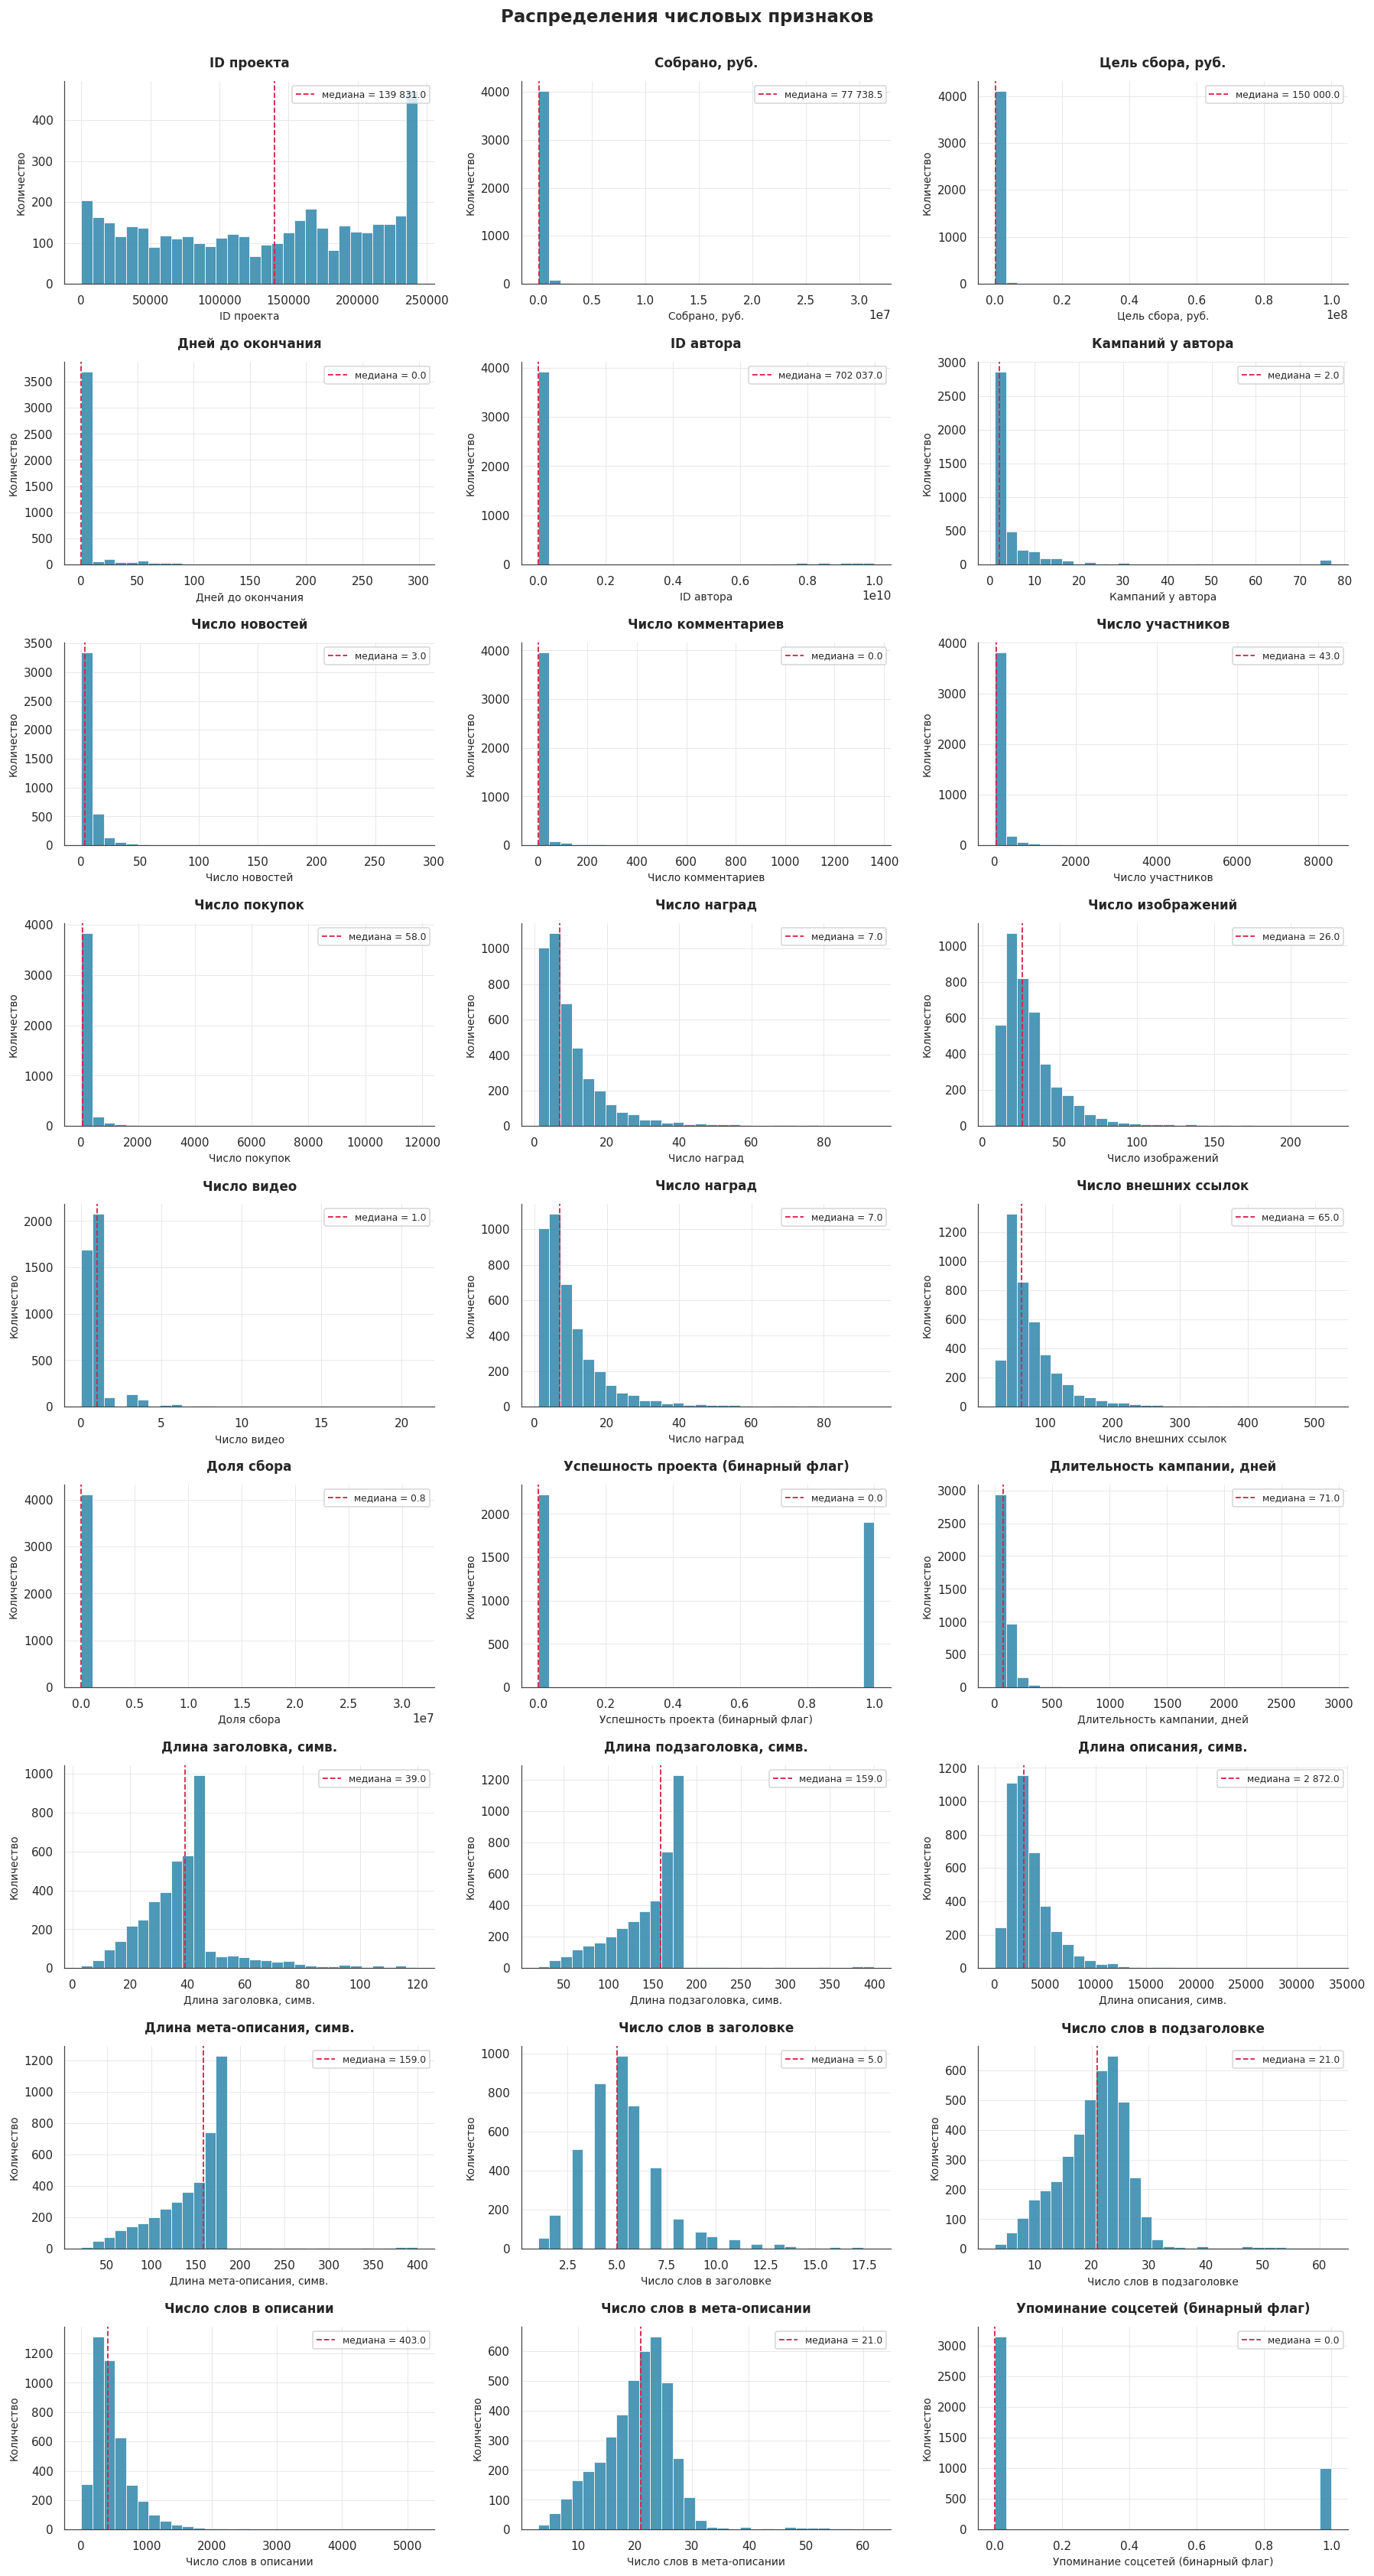

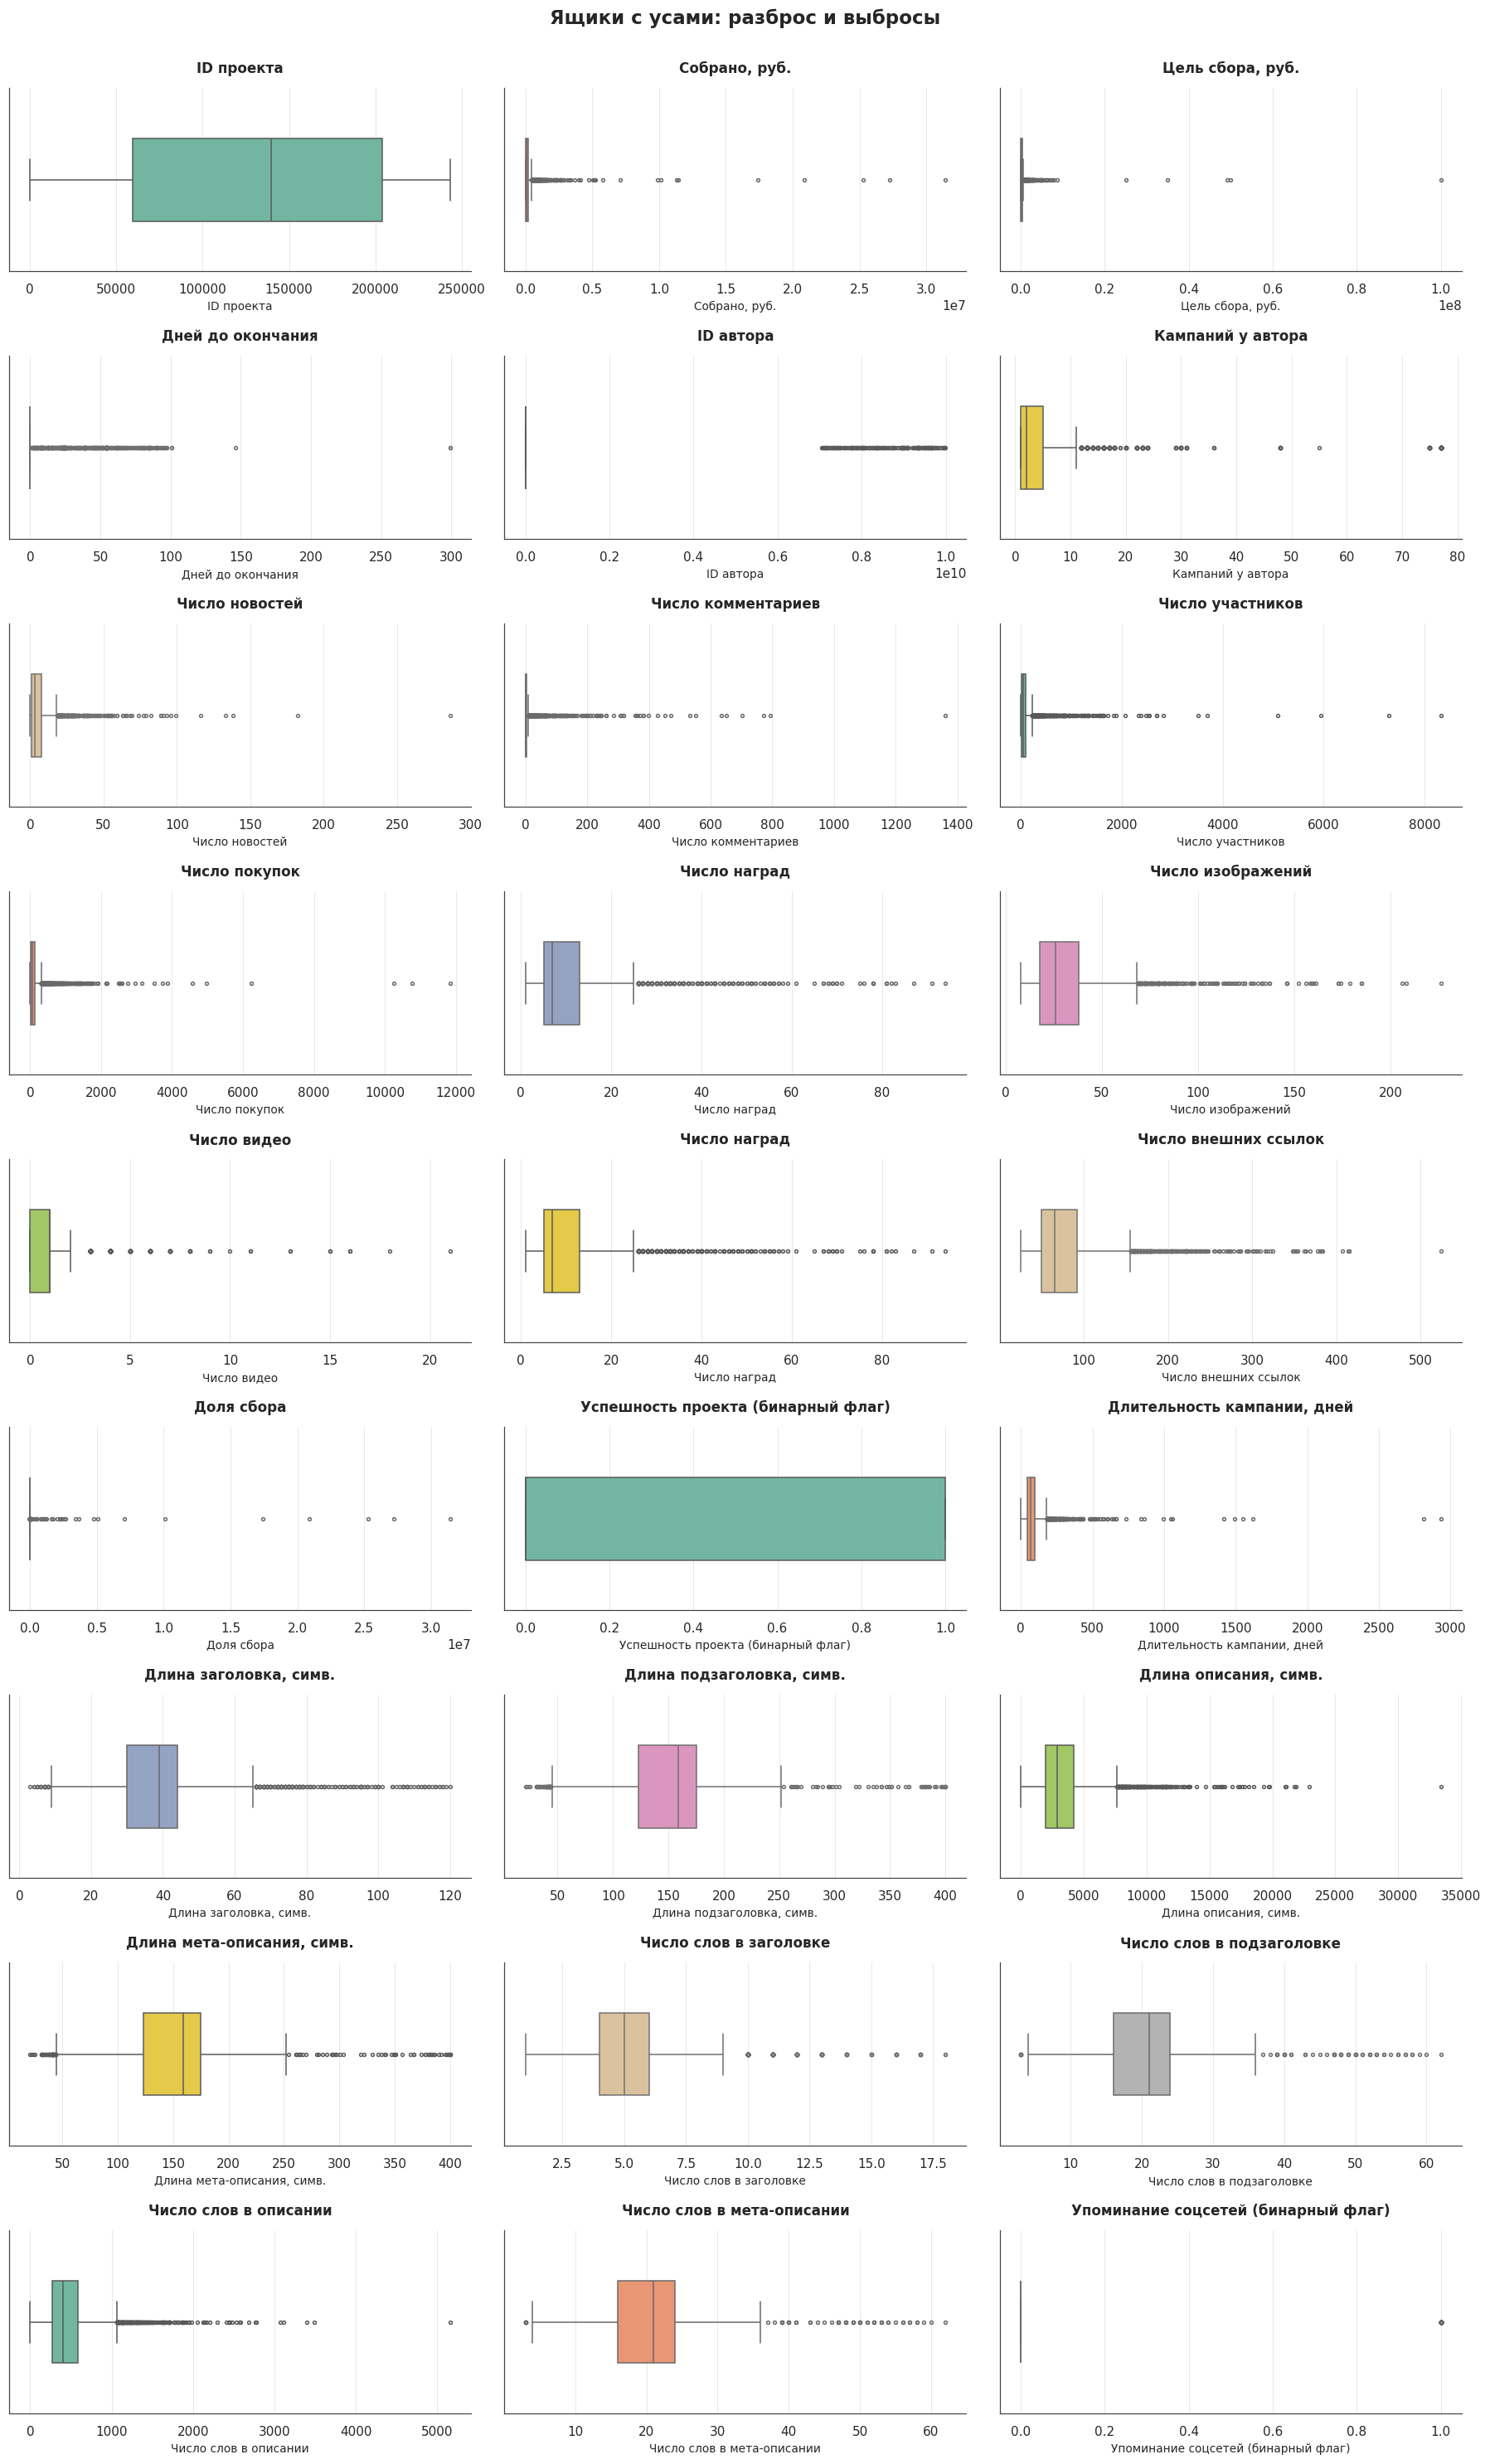

/var/folders/2l/n72xwmrs7sv8qw6zsw6flx4w0000gn/T/ipykernel_69172/2311643880.py:240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/2l/n72xwmrs7sv8qw6zsw6flx4w0000gn/T/ipykernel_69172/2311643880.py:240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/2l/n72xwmrs7sv8qw6zsw6flx4w0000gn/T/ipykernel_69172/2311643880.py:240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/2l/n72xwmrs7sv8qw6zsw6flx4w0000gn/T/ipykernel_69172/2311643880.py:240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecat

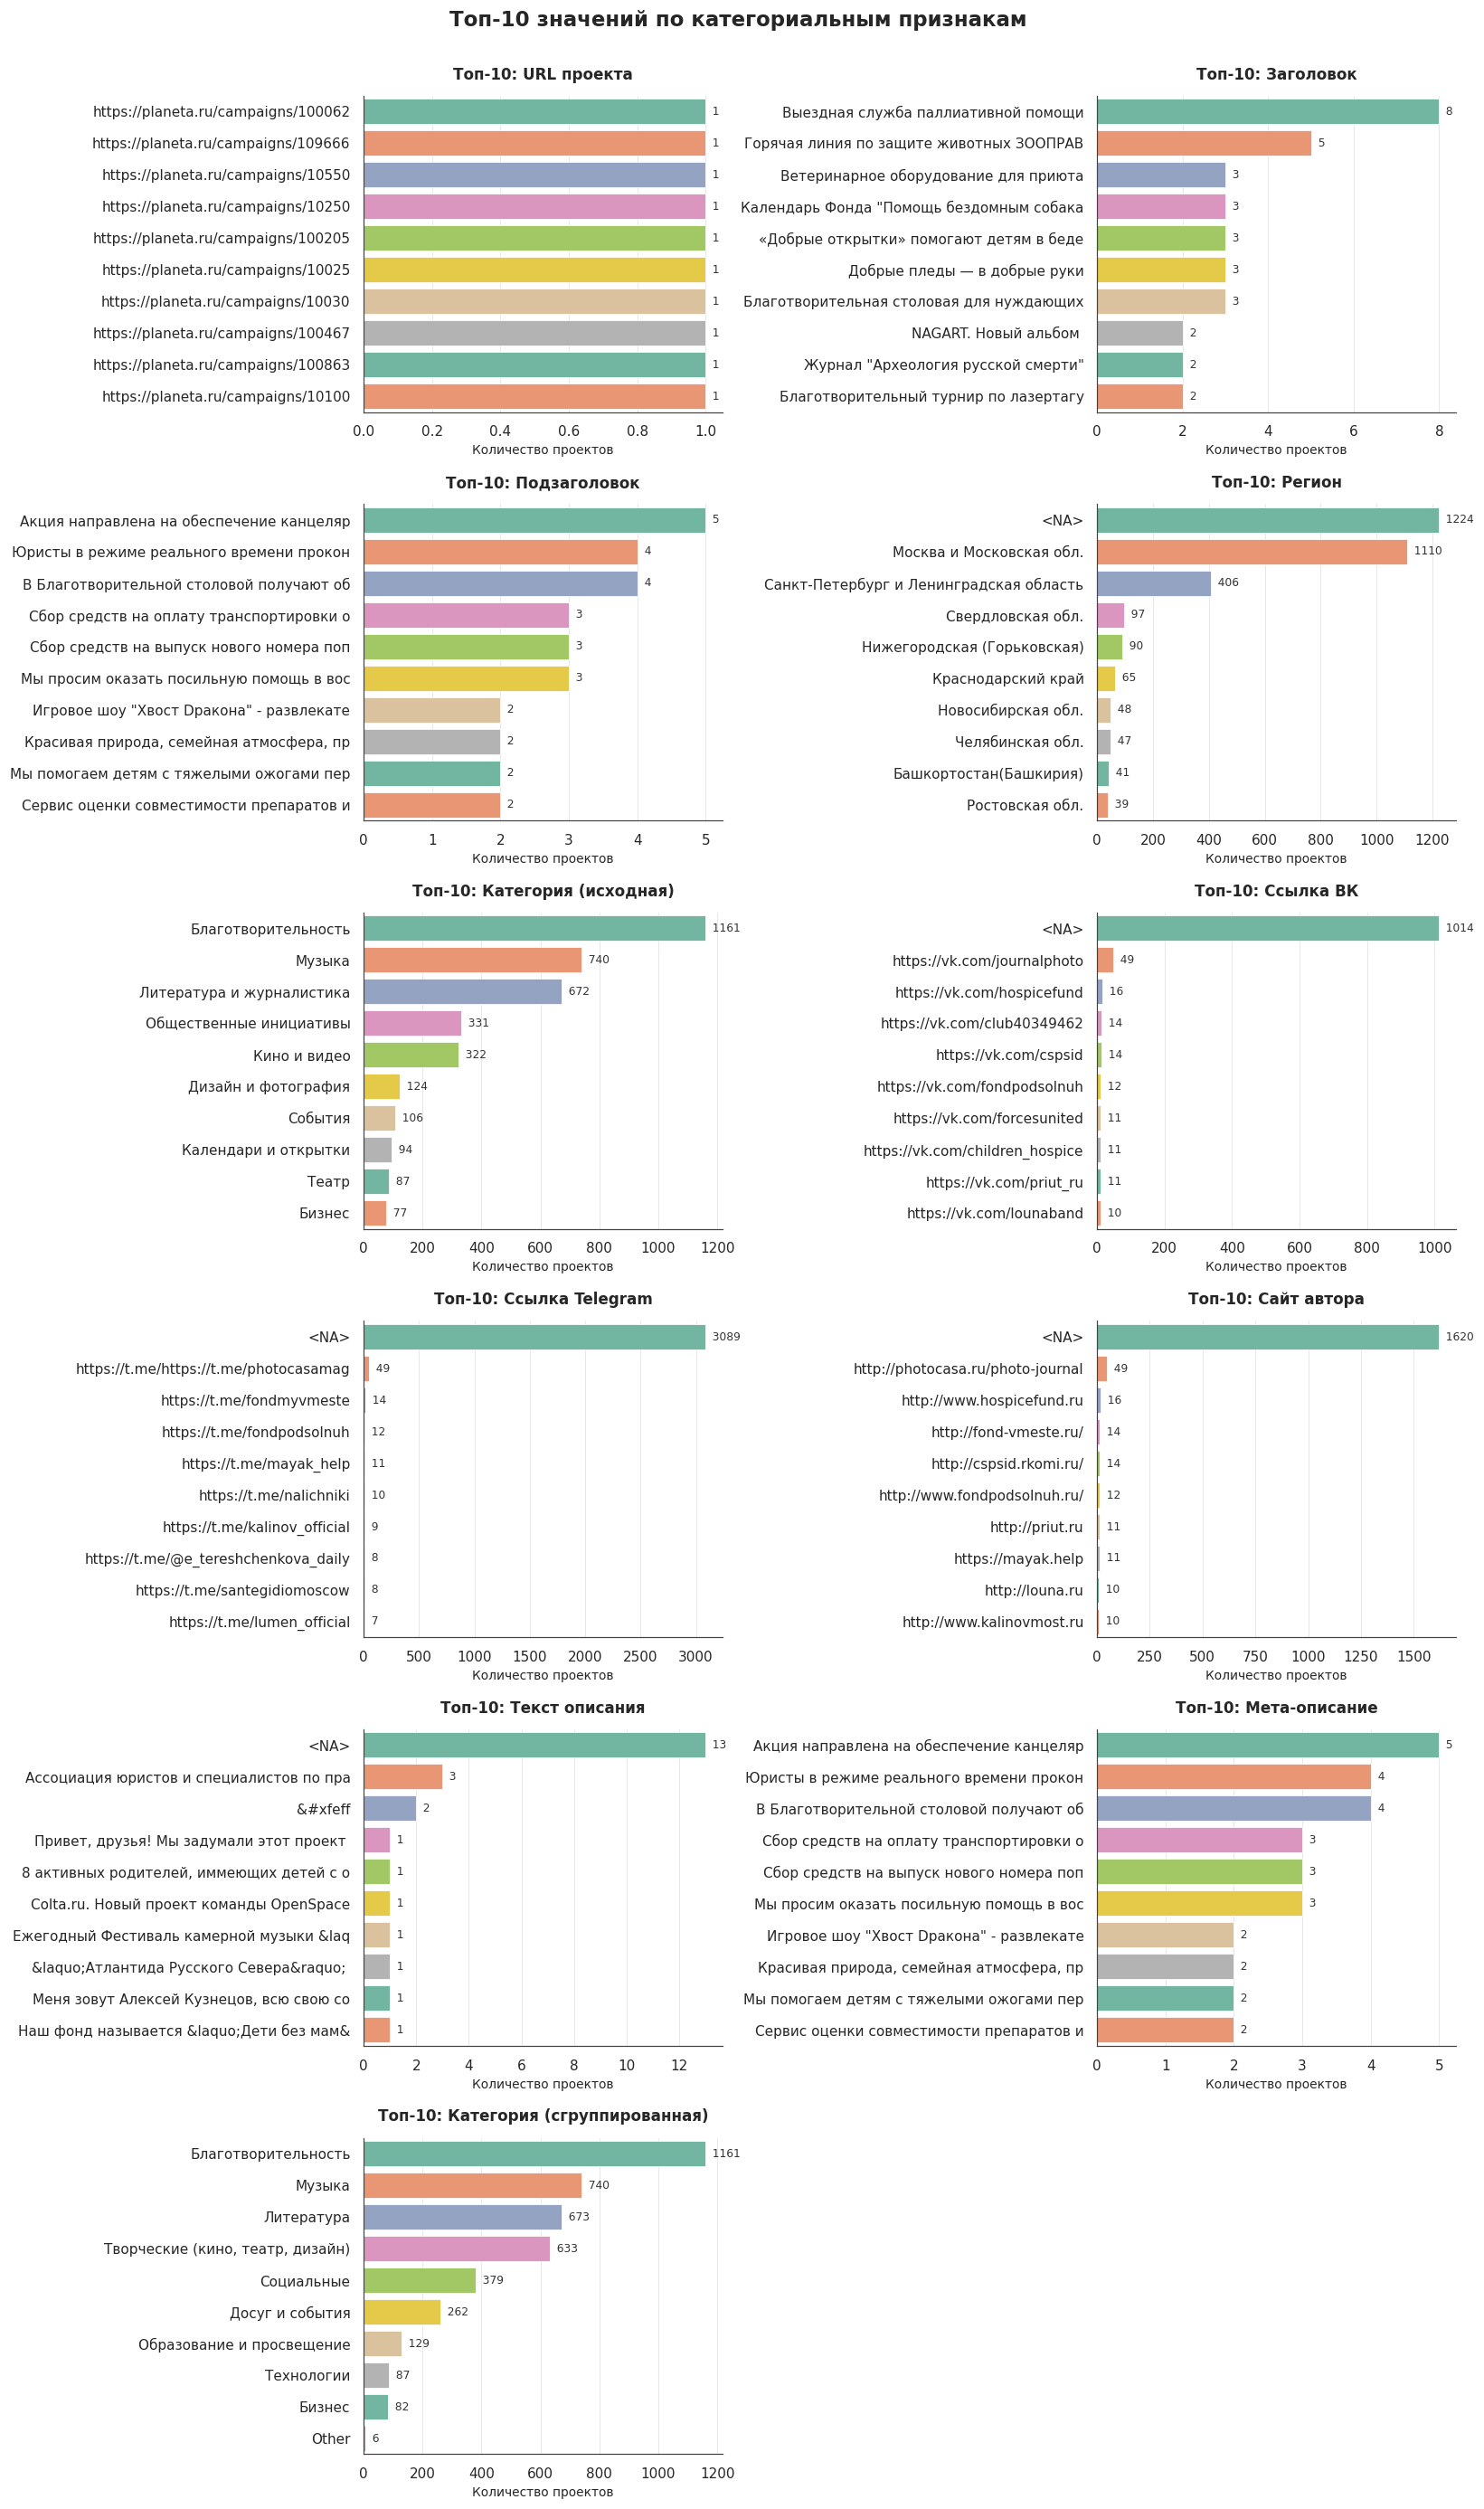

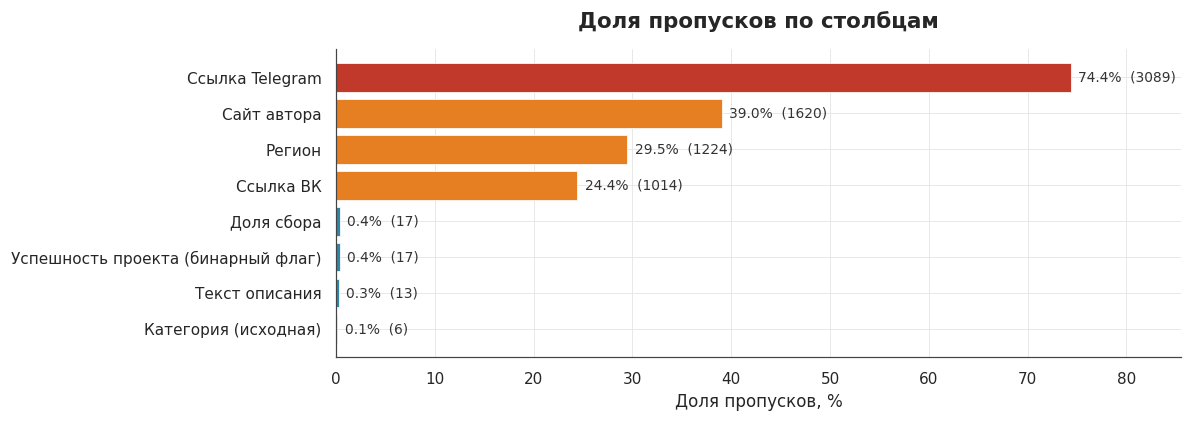

/var/folders/2l/n72xwmrs7sv8qw6zsw6flx4w0000gn/T/ipykernel_69172/2311643880.py:293: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


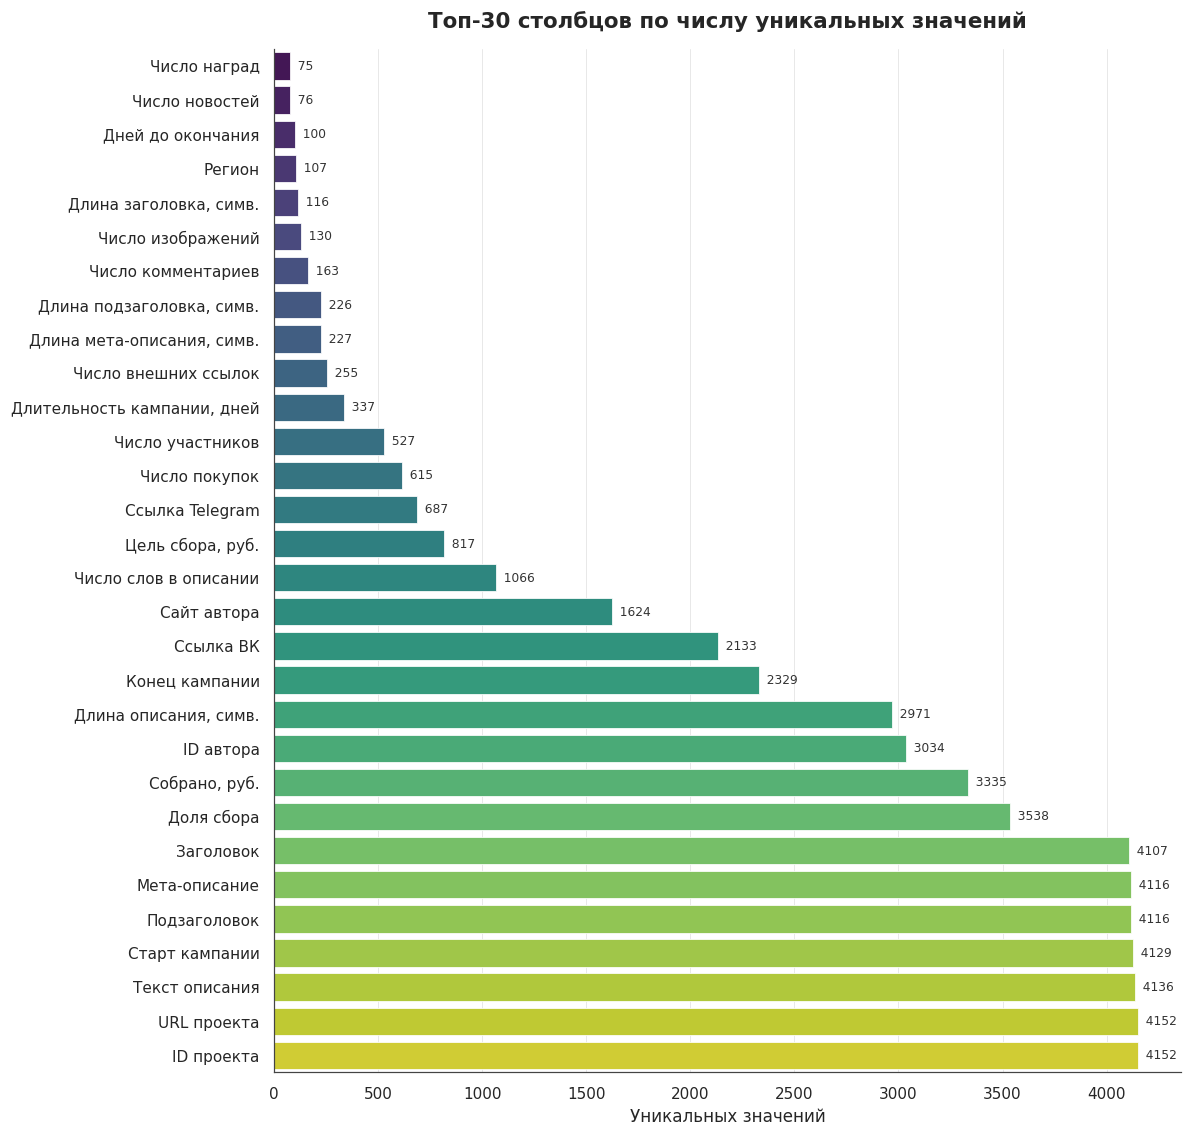

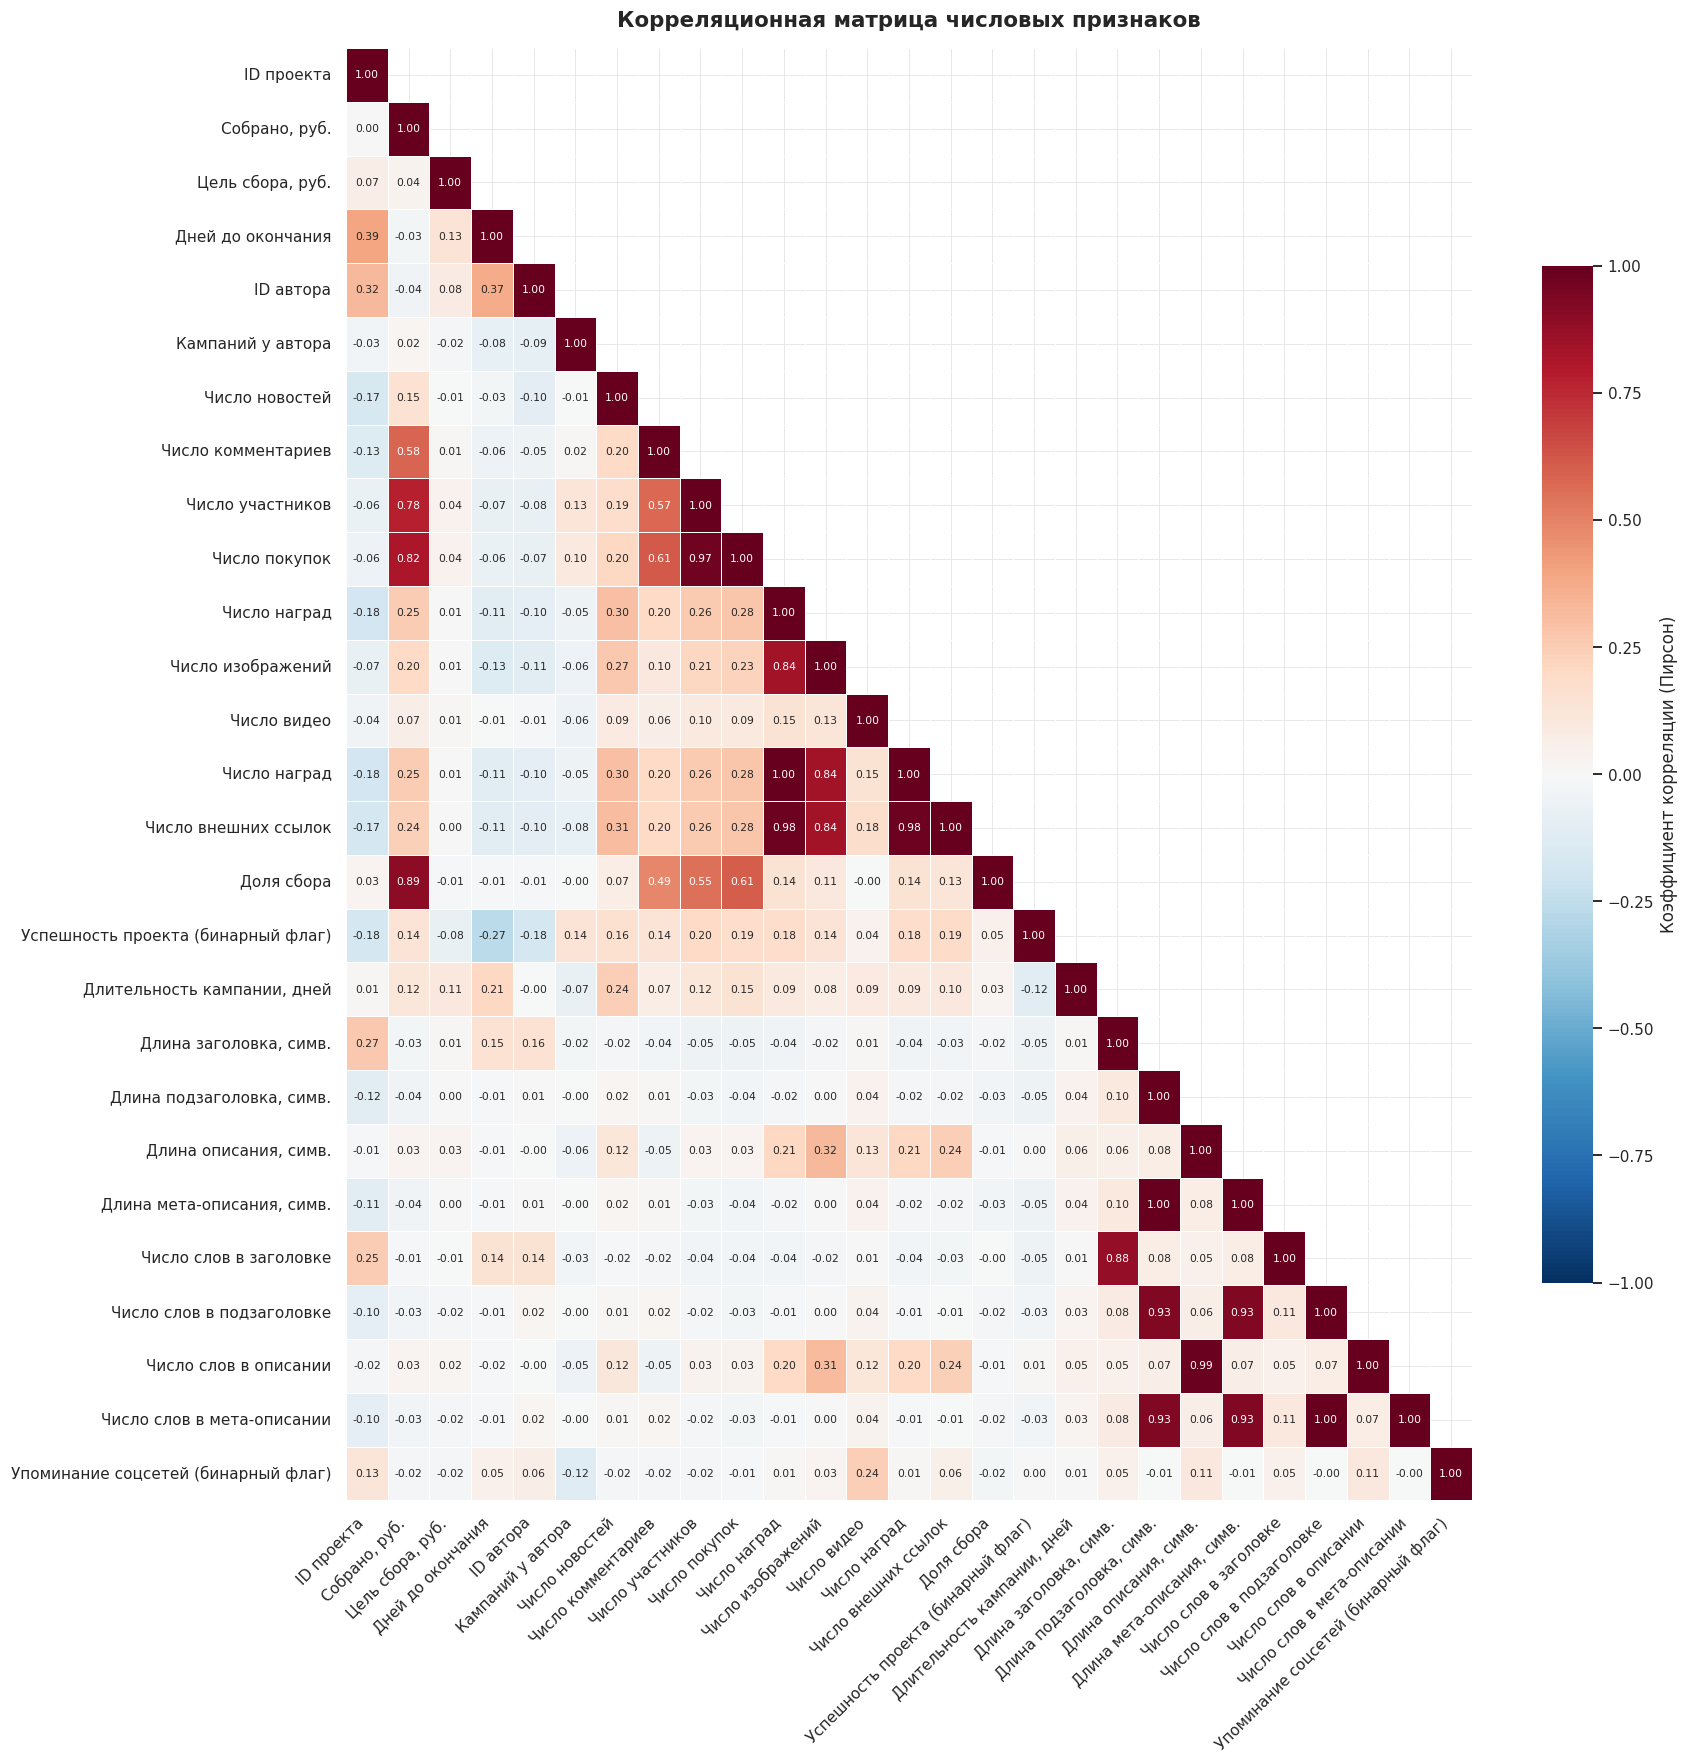


=== СРЕДНИЕ ПО is_successful ===
is_successful                               0                1
project_key                     144718.274809     116478.65304
card.collectedAmount.value       99081.725191    376644.550839
card.targetAmount.value         513477.261787    198202.481132
card.daysToFinish                    9.132465         0.270964
card.author.id               788048796.625954  89747246.472222
card.author.campaignsAmount           3.75797         6.688679
counts.newsCount                     4.463404         7.907757
counts.commentsCount                 3.796587        16.966457
counts.participantsCount            57.443646       181.809224
counts.purchasesCount               77.308487       233.446017
rewards.totalRewards                 8.760216        12.303983
image_count                         28.982039        34.704403
video_count                          0.802425         0.905136
reward_count                         8.760216        12.303983
external_link_count  

In [19]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 0. Базовая настройка
# =========================
df = projects_df.copy()

for col in df.columns:
    if pd.api.types.is_datetime64tz_dtype(df[col]):
        df[col] = df[col].dt.tz_localize(None)

numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
datetime_cols = df.select_dtypes(include=["datetime64[ns]"]).columns.tolist()
string_cols = df.select_dtypes(include=["string", "object"]).columns.tolist()

print("Размер датасета:", df.shape)
print("\nТипы данных:")
print(df.dtypes)

# =========================
# 1. Общая сводка по столбцам
# =========================
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_missing_count": df.notna().sum(),
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().sum() / len(df) * 100).round(2),
    "unique_count": df.nunique(dropna=True)
}).sort_values(["missing_count", "unique_count"], ascending=[False, False])

print("\n=== СВОДКА ПО СТОЛБЦАМ ===")
print(summary)

# =========================
# 2. Описательная статистика по числовым столбцам
# =========================
if numeric_cols:
    numeric_stats = df[numeric_cols].describe().T
    numeric_stats["median"] = df[numeric_cols].median()
    numeric_stats["mode"] = df[numeric_cols].mode(dropna=True).iloc[0]
    numeric_stats["skew"] = df[numeric_cols].skew()
    numeric_stats["missing_count"] = df[numeric_cols].isna().sum()
    numeric_stats["missing_percent"] = (df[numeric_cols].isna().sum() / len(df) * 100).round(2)
    numeric_stats["unique_count"] = df[numeric_cols].nunique(dropna=True)

    outlier_counts = {}
    outlier_percent = {}

    for col in numeric_cols:
        s = df[col].dropna()
        if len(s) == 0:
            outlier_counts[col] = np.nan
            outlier_percent[col] = np.nan
            continue

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        if pd.isna(iqr) or iqr == 0:
            mask = pd.Series(False, index=df.index)
        else:
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            mask = (df[col] < lower) | (df[col] > upper)

        outlier_counts[col] = int(mask.sum())
        outlier_percent[col] = round(mask.mean() * 100, 2)

    numeric_stats["outliers_count"] = pd.Series(outlier_counts)
    numeric_stats["outliers_percent"] = pd.Series(outlier_percent)

    print("\n=== ОПИСАТЕЛЬНАЯ СТАТИСТИКА ПО ЧИСЛОВЫМ ПРИЗНАКАМ ===")
    print(numeric_stats.sort_values("outliers_count", ascending=False))

# =========================
# 3. Сводка по категориальным столбцам
# =========================
if string_cols:
    cat_rows = []
    for col in string_cols:
        s = df[col]
        mode_vals = s.mode(dropna=True)
        top_value = mode_vals.iloc[0] if len(mode_vals) > 0 else pd.NA
        top_freq = int(s.value_counts(dropna=True).iloc[0]) if s.nunique(dropna=True) > 0 else 0

        cat_rows.append({
            "column": col,
            "non_missing_count": s.notna().sum(),
            "missing_count": s.isna().sum(),
            "missing_percent": round(s.isna().mean() * 100, 2),
            "unique_count": s.nunique(dropna=True),
            "top_value": top_value,
            "top_freq": top_freq
        })

    categorical_stats = pd.DataFrame(cat_rows).set_index("column").sort_values(
        ["unique_count", "missing_count"], ascending=[False, False]
    )

    print("\n=== СВОДКА ПО КАТЕГОРИАЛЬНЫМ ПРИЗНАКАМ ===")
    print(categorical_stats)

# =========================
# 4. Сводка по датам
# =========================
if datetime_cols:
    date_rows = []
    for col in datetime_cols:
        s = df[col]
        date_rows.append({
            "column": col,
            "non_missing_count": s.notna().sum(),
            "missing_count": s.isna().sum(),
            "missing_percent": round(s.isna().mean() * 100, 2),
            "min_date": s.min(),
            "max_date": s.max(),
            "unique_count": s.nunique(dropna=True)
        })

    datetime_stats = pd.DataFrame(date_rows).set_index("column")
    print("\n=== СВОДКА ПО ДАТАМ ===")
    print(datetime_stats)

# =========================
# 5. Таблица пропусков
# =========================
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().sum() / len(df) * 100).round(2),
    "non_missing_count": df.notna().sum()
}).sort_values("missing_count", ascending=False)

print("\n=== ПРОПУСКИ ===")
print(missing)

# =========================
# 6. Количество уникальных значений
# =========================
unique_counts = df.nunique(dropna=True).sort_values(ascending=False)
print("\n=== КОЛИЧЕСТВО УНИКАЛЬНЫХ ЗНАЧЕНИЙ ===")
print(unique_counts)

# =========================
# 7. Корреляции числовых признаков
# =========================
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr(numeric_only=True)
    print("\n=== КОРРЕЛЯЦИИ ===")
    print(corr)

# =========================
# 8. ГРАФИКИ
# =========================

# --------- 8.1 Гистограммы числовых признаков ---------
if numeric_cols:
    n_cols = 3
    n_rows = math.ceil(len(numeric_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 3.4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        series = df[col].dropna()

        if len(series) > 0:
            sns.histplot(
                series, bins=30, ax=ax,
                color=COLOR_PRIMARY, edgecolor="white", linewidth=0.5,
                alpha=0.85,
            )
            med = series.median()
            ax.axvline(med, color=COLOR_FAIL, linestyle="--", linewidth=1.2,
                       label=f"медиана = {med:,.1f}".replace(",", " "))
            ax.legend(loc="upper right", fontsize=8)
            ax.set_title(label(col), fontsize=11)
            ax.set_xlabel(label(col), fontsize=9)
            ax.set_ylabel("Количество", fontsize=9)
        else:
            ax.set_title(f"{label(col)}\n(нет данных)", fontsize=11)
            ax.set_axis_off()

    for j in range(len(numeric_cols), len(axes)):
        axes[j].axis("off")

    fig.suptitle("Распределения числовых признаков", y=1.0, fontsize=15)
    plt.tight_layout()
    plt.show()

# --------- 8.2 Ящики с усами (boxplots) ---------
if numeric_cols:
    n_cols = 3
    n_rows = math.ceil(len(numeric_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 3.0 * n_rows))
    axes = np.array(axes).reshape(-1)

    palette = sns.color_palette("Set2", n_colors=len(numeric_cols))

    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        series = df[col].dropna()

        if len(series) > 0:
            sns.boxplot(
                x=series, ax=ax,
                color=palette[i % len(palette)],
                width=0.45, fliersize=2.5, linewidth=1.0,
            )
            ax.set_title(label(col), fontsize=11)
            ax.set_xlabel(label(col), fontsize=9)
        else:
            ax.set_title(f"{label(col)}\n(нет данных)", fontsize=11)
            ax.set_axis_off()

    for j in range(len(numeric_cols), len(axes)):
        axes[j].axis("off")

    fig.suptitle("Ящики с усами: разброс и выбросы", y=1.0, fontsize=15)
    plt.tight_layout()
    plt.show()

# --------- 8.3 Топ-10 категорий по строковым столбцам ---------
if string_cols:
    n_cols = 2
    n_rows = math.ceil(len(string_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7.5 * n_cols, 4.2 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(string_cols):
        ax = axes[i]
        vc = df[col].value_counts(dropna=False).head(10)

        if len(vc) > 0:
            categories = [str(x)[:40] for x in vc.index]
            sns.barplot(
                x=vc.values, y=categories, ax=ax,
                palette="Set2", edgecolor="white", linewidth=0.5,
            )
            ax.set_title(f"Топ-10: {label(col)}", fontsize=11)
            ax.set_xlabel("Количество проектов", fontsize=9)
            ax.set_ylabel("")
            for j_, v in enumerate(vc.values):
                ax.text(v, j_, f"  {int(v)}", va="center", fontsize=8, color="#333333")
        else:
            ax.set_title(f"Топ-10: {label(col)}\n(нет данных)", fontsize=11)
            ax.set_axis_off()

    for j in range(len(string_cols), len(axes)):
        axes[j].axis("off")

    fig.suptitle("Топ-10 значений по категориальным признакам", y=1.0, fontsize=15)
    plt.tight_layout()
    plt.show()

# --------- 8.4 Доля пропусков ---------
missing_nonzero = missing[missing["missing_count"] > 0].copy()

if len(missing_nonzero) > 0:
    fig, ax = plt.subplots(figsize=(11, max(4, len(missing_nonzero) * 0.4)))
    rus_index = [label(c) for c in missing_nonzero.index[::-1]]
    pcts = missing_nonzero["missing_percent"][::-1].values
    counts = missing_nonzero["missing_count"][::-1].values

    bar_colors = ["#c0392b" if p >= 50 else ("#e67e22" if p >= 20 else COLOR_PRIMARY)
                  for p in pcts]

    bars = ax.barh(rus_index, pcts, color=bar_colors, edgecolor="white", linewidth=0.5)
    ax.set_title("Доля пропусков по столбцам", fontsize=14, pad=14)
    ax.set_xlabel("Доля пропусков, %", fontsize=11)
    ax.set_ylabel("")
    ax.set_xlim(0, max(pcts) * 1.15)

    for bar, pct, cnt in zip(bars, pcts, counts):
        ax.text(
            bar.get_width() + max(pcts) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%  ({int(cnt)})",
            va="center", fontsize=9, color="#333333",
        )

    plt.tight_layout()
    plt.show()

# --------- 8.5 Уникальные значения по столбцам ---------
fig, ax = plt.subplots(figsize=(11, max(4, len(unique_counts.head(30)) * 0.35)))
top_unique = unique_counts.head(30).sort_values()
rus_index = [label(c) for c in top_unique.index]
sns.barplot(
    x=top_unique.values, y=rus_index, ax=ax,
    palette="viridis", edgecolor="white", linewidth=0.5,
)
ax.set_title("Топ-30 столбцов по числу уникальных значений", fontsize=14, pad=14)
ax.set_xlabel("Уникальных значений", fontsize=11)
ax.set_ylabel("")
for i, v in enumerate(top_unique.values):
    ax.text(v, i, f"  {int(v)}", va="center", fontsize=8, color="#333333")
plt.tight_layout()
plt.show()

# --------- 8.6 Корреляционная матрица ---------
if len(numeric_cols) >= 2:
    corr_matrix = df[numeric_cols].corr(numeric_only=True)
    rus_labels = [label(c) for c in corr_matrix.columns]

    fig, ax = plt.subplots(
        figsize=(max(9, len(corr_matrix) * 0.6), max(7, len(corr_matrix) * 0.6))
    )

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(
        corr_matrix, mask=mask, ax=ax,
        cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        annot=True, fmt=".2f", annot_kws={"size": 7},
        linewidths=0.4, linecolor="white",
        cbar_kws={"label": "Коэффициент корреляции (Пирсон)", "shrink": 0.7},
        xticklabels=rus_labels, yticklabels=rus_labels,
    )
    ax.set_title("Корреляционная матрица числовых признаков", fontsize=14, pad=14)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# --------- 8.7 Сравнение по is_successful ---------
if "is_successful" in df.columns and "is_successful" in numeric_cols:
    target_compare_cols = [col for col in numeric_cols if col != "is_successful"]

    if target_compare_cols:
        grouped_mean = df.groupby("is_successful")[target_compare_cols].mean(numeric_only=True).T
        grouped_median = df.groupby("is_successful")[target_compare_cols].median(numeric_only=True).T

        print("\n=== СРЕДНИЕ ПО is_successful ===")
        print(grouped_mean)

        print("\n=== МЕДИАНЫ ПО is_successful ===")
        print(grouped_median)

# =========================
# 9. СОХРАНЕНИЕ В EXCEL
# =========================
with pd.ExcelWriter("eda_full_summary.xlsx") as writer:
    summary.to_excel(writer, sheet_name="summary")

    if numeric_cols:
        numeric_stats.to_excel(writer, sheet_name="numeric_stats")

    if string_cols:
        categorical_stats.to_excel(writer, sheet_name="categorical_stats")

    if datetime_cols:
        datetime_stats.to_excel(writer, sheet_name="datetime_stats")

    missing.to_excel(writer, sheet_name="missing")
    unique_counts.to_frame("unique_count").to_excel(writer, sheet_name="unique_counts")

    if len(numeric_cols) >= 2:
        corr.to_excel(writer, sheet_name="correlations")

print("\nEDA завершен. Файл сохранен: eda_full_summary.xlsx")


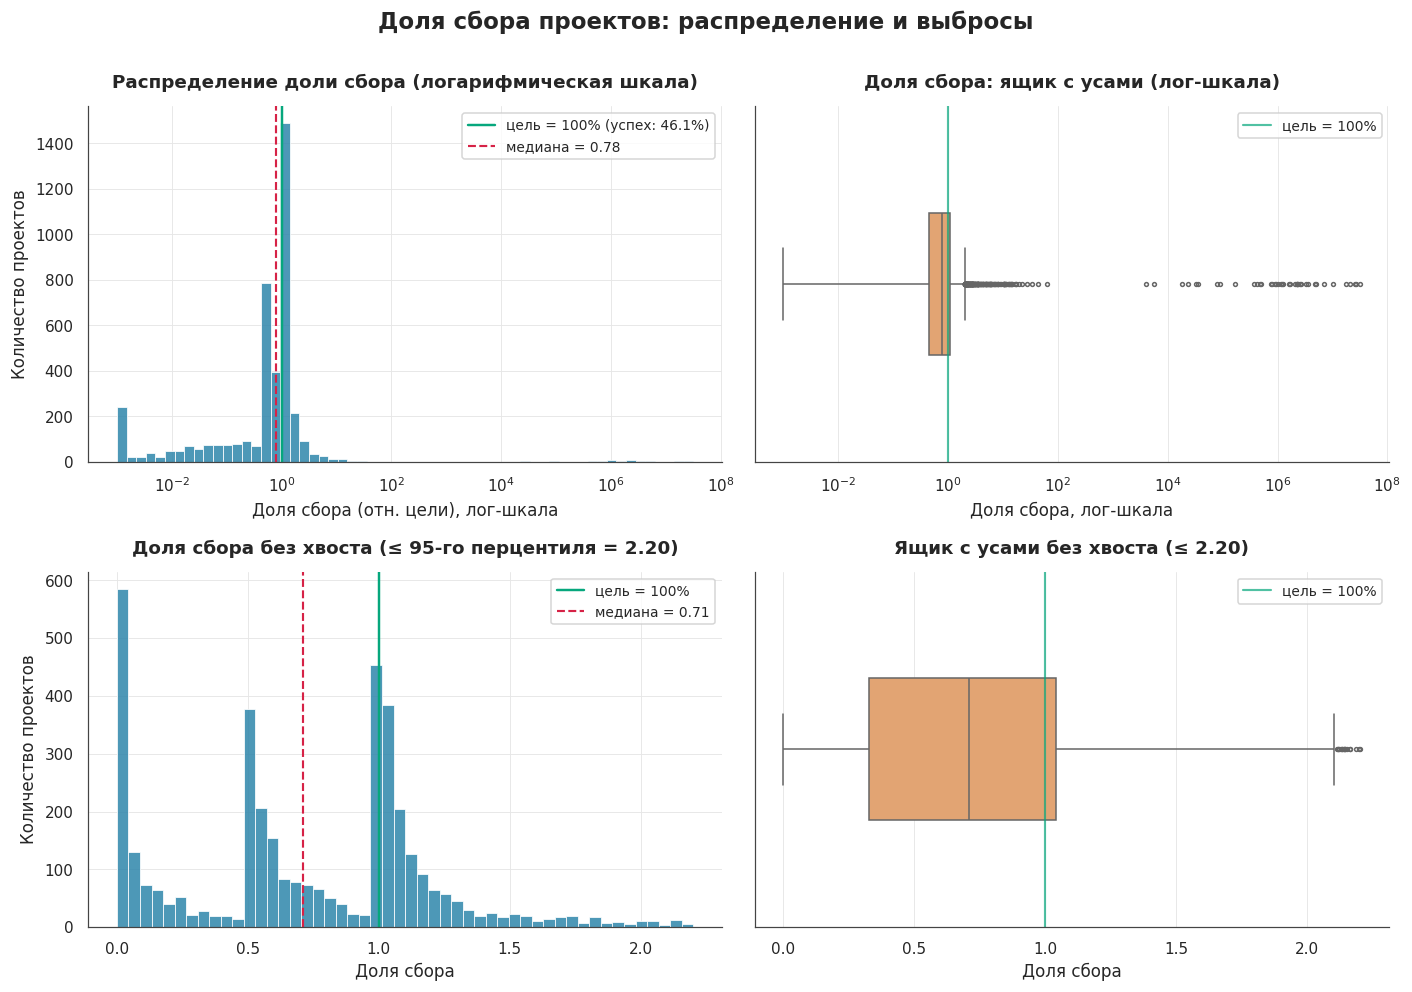

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Распределение доли сбора (funding_ratio)
fr = projects_df["funding_ratio"].dropna()
p95 = fr.quantile(0.95)
fr_trimmed = fr[fr <= p95]

med_full = fr.median()
med_trim = fr_trimmed.median()
share_success = (fr >= 1).mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Гистограмма (полная, лог-шкала по X для удобства)
ax = axes[0, 0]
fr_clip = fr.clip(lower=1e-3)  # log нельзя для 0
sns.histplot(fr_clip, bins=60, ax=ax, color=COLOR_PRIMARY,
             edgecolor="white", linewidth=0.5, log_scale=(True, False), alpha=0.85)
ax.axvline(1, color=COLOR_SUCCESS, linestyle="-", linewidth=1.6,
           label=f"цель = 100% (успех: {share_success:.1f}%)")
ax.axvline(med_full, color=COLOR_FAIL, linestyle="--", linewidth=1.4,
           label=f"медиана = {med_full:.2f}")
ax.set_title("Распределение доли сбора (логарифмическая шкала)", fontsize=12)
ax.set_xlabel("Доля сбора (отн. цели), лог-шкала")
ax.set_ylabel("Количество проектов")
ax.legend(loc="upper right", fontsize=9)

# 2. Ящик с усами — полная выборка (лог-шкала)
ax = axes[0, 1]
sns.boxplot(x=fr_clip, ax=ax, color=COLOR_ACCENT,
            width=0.4, fliersize=2.5, linewidth=1.0)
ax.set_xscale("log")
ax.set_title("Доля сбора: ящик с усами (лог-шкала)", fontsize=12)
ax.set_xlabel("Доля сбора, лог-шкала")
ax.axvline(1, color=COLOR_SUCCESS, linestyle="-", linewidth=1.4,
           alpha=0.7, label="цель = 100%")
ax.legend(loc="upper right", fontsize=9)

# 3. Гистограмма без экстремальных выбросов (95-й перцентиль)
ax = axes[1, 0]
sns.histplot(fr_trimmed, bins=50, ax=ax, color=COLOR_PRIMARY,
             edgecolor="white", linewidth=0.5, alpha=0.85)
ax.axvline(1, color=COLOR_SUCCESS, linestyle="-", linewidth=1.6,
           label="цель = 100%")
ax.axvline(med_trim, color=COLOR_FAIL, linestyle="--", linewidth=1.4,
           label=f"медиана = {med_trim:.2f}")
ax.set_title(f"Доля сбора без хвоста (≤ 95-го перцентиля = {p95:.2f})", fontsize=12)
ax.set_xlabel("Доля сбора")
ax.set_ylabel("Количество проектов")
ax.legend(loc="upper right", fontsize=9)

# 4. Ящик с усами — усечённая выборка
ax = axes[1, 1]
sns.boxplot(x=fr_trimmed, ax=ax, color=COLOR_ACCENT,
            width=0.4, fliersize=2.5, linewidth=1.0)
ax.set_title(f"Ящик с усами без хвоста (≤ {p95:.2f})", fontsize=12)
ax.set_xlabel("Доля сбора")
ax.axvline(1, color=COLOR_SUCCESS, linestyle="-", linewidth=1.4,
           alpha=0.7, label="цель = 100%")
ax.legend(loc="upper right", fontsize=9)

fig.suptitle("Доля сбора проектов: распределение и выбросы",
             fontsize=15, y=1.0)
plt.tight_layout()
plt.show()


In [21]:
projects_df["card.mainCategory.tagName"].value_counts()

card.mainCategory.tagName
Благотворительность               1161
Музыка                             740
Литература и журналистика          672
Общественные инициативы            331
Кино и видео                       322
Дизайн и фотография                124
События                            106
Календари и открытки                94
Театр                               87
Бизнес                              77
Технологии и инновации              67
Наука и просвещение                 66
Спорт                               52
Обучение                            49
Игры                                47
Социальное предпринимательство      32
Путешествия                         30
Приложения                          16
Экология и природа                  15
Еда                                 11
Импульс                             11
Онлайн-кампус                        8
Библиотека Ridero                    5
Архитектура и Урбанистика            3
Битва Технологий                     3

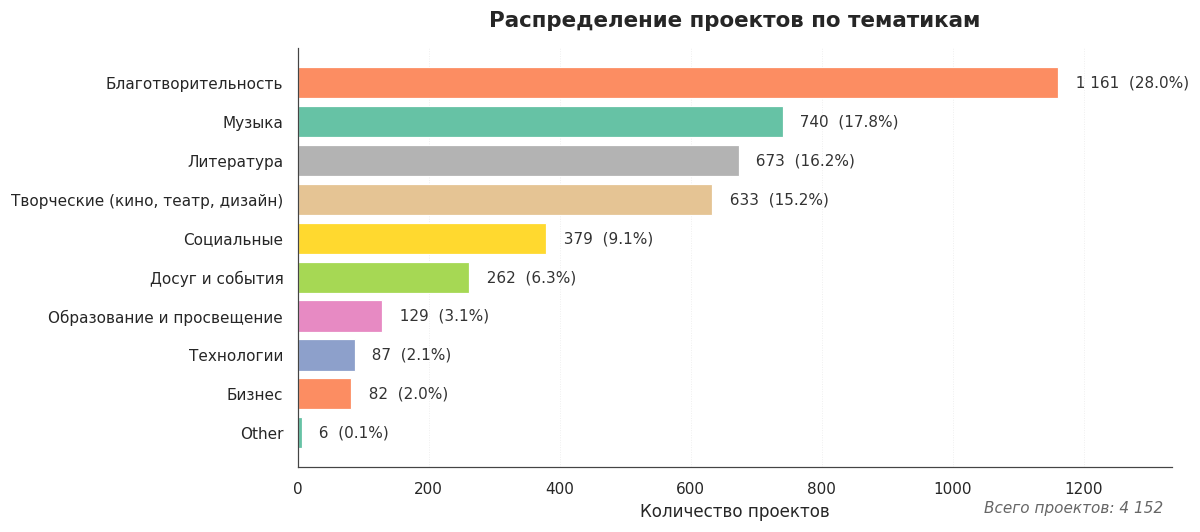

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Распределение проектов по тематикам
category_counts = (
    projects_df["category_grouped"]
    .fillna("Не указано")
    .value_counts()
)

total = category_counts.sum()
category_share = (category_counts / total * 100).round(1)

# Горизонтальный bar — длинные названия читаются лучше
fig, ax = plt.subplots(figsize=(11, max(5, len(category_counts) * 0.45)))
order = category_counts.sort_values(ascending=True)

palette = sns.color_palette("Set2", n_colors=len(order))
bars = ax.barh(
    order.index, order.values,
    color=palette, edgecolor="white", linewidth=0.8,
)

ax.set_title("Распределение проектов по тематикам", fontsize=14, pad=14)
ax.set_xlabel("Количество проектов", fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, order.values.max() * 1.15)

# Числа и доли на барах
for bar, n in zip(bars, order.values):
    pct = n / total * 100
    ax.text(
        bar.get_width() + order.values.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"  {int(n):,}".replace(",", " ") + f"  ({pct:.1f}%)",
        va="center", fontsize=10, color="#333333",
    )

# Скрываем правую и верхнюю рамки уже глобально, тут добавим лёгкую сетку
ax.grid(axis="x", linestyle=":", linewidth=0.6, alpha=0.7)
ax.grid(axis="y", visible=False)

# Подпись с общим количеством
ax.text(
    0.99, -0.08,
    f"Всего проектов: {total:,}".replace(",", " "),
    transform=ax.transAxes, ha="right", va="top",
    fontsize=10, color="#666666", style="italic",
)

plt.tight_layout()
plt.show()


Всего проектов: 4152
Успешные:    1908  (46.0%)
Неуспешные:  2227  (53.6%)
Не определено: 17  (0.4%)


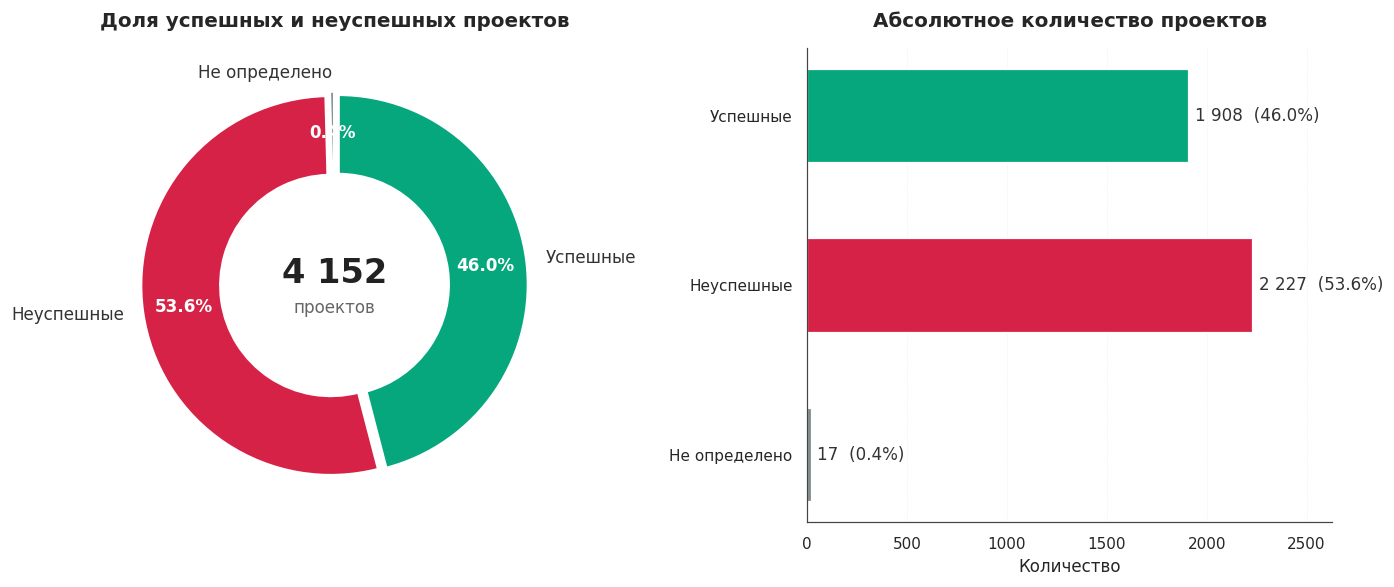

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Доля успешных и неуспешных проектов
counts = projects_df["is_successful"].value_counts(dropna=False)
n_success = int(counts.get(1, 0))
n_fail    = int(counts.get(0, 0))
n_unknown = int(counts.drop([0, 1], errors="ignore").sum())
total     = n_success + n_fail + n_unknown

values = [n_success, n_fail] + ([n_unknown] if n_unknown else [])
labels_ = ["Успешные", "Неуспешные"] + (["Не определено"] if n_unknown else [])
colors_ = [COLOR_SUCCESS, COLOR_FAIL] + ([COLOR_NEUTRAL] if n_unknown else [])
explode_ = [0.02] * len(values)

print(f"Всего проектов: {total}")
print(f"Успешные:   {n_success:>5}  ({n_success/total*100:.1f}%)")
print(f"Неуспешные: {n_fail:>5}  ({n_fail/total*100:.1f}%)")
if n_unknown:
    print(f"Не определено: {n_unknown}  ({n_unknown/total*100:.1f}%)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5),
                                gridspec_kw={"width_ratios": [1.05, 1]})

# Левая панель — donut chart
wedges, texts, autotexts = ax1.pie(
    values,
    labels=labels_,
    colors=colors_,
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
    counterclock=False,
    explode=explode_,
    pctdistance=0.78,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=11, color="#333333"),
)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")
    autotext.set_fontsize(11)

# Центральная подпись внутри донута
ax1.text(0, 0.06, f"{total:,}".replace(",", " "),
         ha="center", va="center", fontsize=22, fontweight="bold",
         color="#222222")
ax1.text(0, -0.12, "проектов", ha="center", va="center",
         fontsize=11, color="#666666")
ax1.set_title("Доля успешных и неуспешных проектов", fontsize=13, pad=14)

# Правая панель — горизонтальный бар с числами
ax2.barh(labels_[::-1], values[::-1], color=colors_[::-1],
         edgecolor="white", linewidth=0.8, height=0.55)
ax2.set_title("Абсолютное количество проектов", fontsize=13, pad=14)
ax2.set_xlabel("Количество")
ax2.set_xlim(0, max(values) * 1.18)
for i, v in enumerate(values[::-1]):
    pct = v / total * 100
    ax2.text(
        v + max(values) * 0.015, i,
        f"{v:,}".replace(",", " ") + f"  ({pct:.1f}%)",
        va="center", fontsize=11, color="#333333",
    )
ax2.grid(axis="x", linestyle=":", linewidth=0.6, alpha=0.7)
ax2.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()


In [24]:
projects_df.groupby("is_successful")[numeric_cols].median()

,project_key,card.collectedAmount.value,card.targetAmount.value,card.daysToFinish,card.author.id,card.author.campaignsAmount,counts.newsCount,counts.commentsCount,counts.participantsCount,counts.purchasesCount,...,campaign_duration_days,title_len_chars,subtitle_len_chars,description_len_chars,meta_description_len_chars,title_word_count,subtitle_word_count,description_word_count,meta_description_word_count,description_has_link_word
is_successful,,,,,,,,,,,,,,,,,,,,,
0,157637.0,36300.0,200000.0,0.0,834554.0,1.0,2.0,0.0,27.0,35.0,...,84.0,39.0,162.0,2938.0,162.0,5.0,21.0,410.0,21.0,0.0
1,119936.5,139115.0,100000.0,0.0,554042.0,2.0,4.0,2.0,75.0,98.0,...,59.0,38.0,156.0,2789.0,156.0,5.0,21.0,393.0,21.0,0.0


In [25]:
projects_df.to_excel("projects_planeta.xlsx", index=False)